# Robustness of Graph Neural Networks at Scale - Quick Start

This notebook can be run in google colab and serves as a quick introduction to the [Robustness of Graph Neural Networks at Scale](https://github.com/sigeisler/robustness_of_gnns_at_scale) repository.

## 0. Setup

First, let's get the code and install requirements.


In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import AttackerGNN.MainAttack
import config
%cd {config.PROJECT_DIR}

E:\Masterarbeit\AttackerGNN


E:\Anaconda\envs\Masterarbeit\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


### Imports

In [2]:
# run
from timeit import default_timer as timer
import seml

In [3]:
#7 run
#%cd robustness_of_gnns_at_scale
from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)

%matplotlib inline

%load_ext autoreload
%autoreload 2

Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[01/09/26 14:27:07] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=435934;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=712134;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[01/09/26 14:27:07] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=908405;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=20040;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

## 1. Training

For the training and evaluation code we decided to provide Sacred experiments which make it very easy to run the same code from the command line or on your cluster. To train or attack the models you can use the `script_execute_experiment` script and simply specify the respective configuration or execute the experiment directly by passing the desired configuration in [experiments/experiment_train.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_train.py#L74).

In the example below, we train a `GCN` on `Cora ML`.

[01/09/26 14:27:08] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'Vanilla      ]8;id=316283;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=49923;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#140\140]8;;\
                             GCN', 'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters':                         
                             64, 'dropout': 0.5, 'svd_params': None, 'jaccard_params':                             
                             None, 'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                        
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo', 'ppr_cache_params': {},                                 
                             'device': 'cpu', 'display_steps': 100, 'data_device': 'cpu'}                          

                    INFO     Training set size: 140                                         ]8;id=280132;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=53343;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#161\161]8;;\

                    INFO     Validation set size: 140                                       ]8;id=706432;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=515260;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#162\162]8;;\

                    INFO     Test set size: 2530                                            ]8;id=372500;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=224686;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#163\163]8;;\

                    INFO     Memory Usage after loading the dataset:                        ]8;id=349130;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=464947;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#183\183]8;;\

...

[01/09/26 14:27:23] INFO                                                                                ]8;id=765735;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=205756;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.06982, loss_val: 0.36410, acc_train: 1.00000,               
                             acc_val: 0.88571                                                                      

[01/09/26 14:27:25] INFO                                                                                ]8;id=793942;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=643371;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.06437, loss_val: 0.40359, acc_train: 1.00000,               
                             acc_val: 0.87857                                                                      

[01/09/26 14:27:27] INFO     Test accuracy is 0.8351778388023376 with seed 0                ]8;id=16361;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=650678;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Lock 2331099222224 acquired on cache\demo.json.lock                    ]8;id=511534;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=887185;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2331099222224 released on cache\demo.json.lock                    ]8;id=182602;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=270033;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

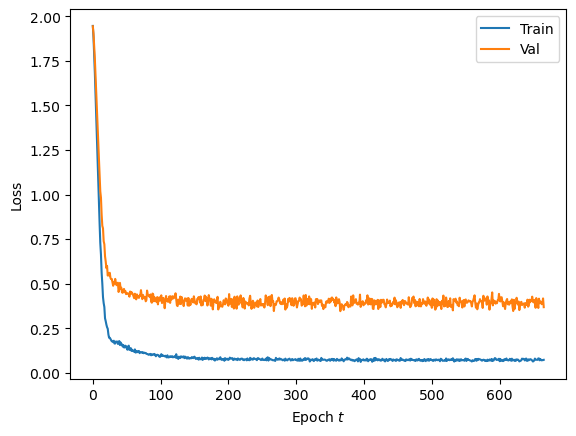

In [4]:
train_statistics = experiment_train.run(
    data_dir = './data',
    dataset = 'cora_ml',
    model_params = dict(
        label="Vanilla GCN",
        model="GCN",
        do_cache_adj_prep=True,
        n_filters=64,
        dropout=0.5,
        svd_params=None,
        jaccard_params=None,
        gdc_params={"alpha": 0.15, "k": 64}),
    train_params = dict(
        lr=1e-2,
        weight_decay=1e-3,
        patience=300,
        max_epochs=3000),
    binary_attr = False,
    make_undirected = True,
    seed=0,
    artifact_dir = 'cache',
    model_storage_type = 'demo',
    ppr_cache_params = dict(),
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    display_steps = 100,
    debug_level = "info"
)

# plot train and val loss curves
fig, ax = plt.subplots()

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.plot(train_statistics['trace_train'], color=color, label='Train')

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
ax.plot(train_statistics['trace_val'], color=color, label='Val')
ax.legend()
"123"
plt.show()

In [5]:
clean_acc = train_statistics["accuracy"]
print(f'Accuracy of the model: {100*clean_acc:.2f}%')

Accuracy of the model: 83.52%


## 1.1 Certificate integration

In [6]:
# certificate integration
import torch
import numpy as np
import copy
from sparse_smoothing.models import GCN
from sparse_smoothing.utils import load_and_standardize

loaded_from_robustness = torch.load(f'cache/demo/demo_1.pt', map_location='cpu', weights_only=False)

trained_state_dict = copy.deepcopy(loaded_from_robustness)

for key in list(trained_state_dict.keys()):
    if 'layers.0.' in key:
        new_key = key.replace('layers.0.gcn_0', 'conv1')
        trained_state_dict[new_key] = trained_state_dict.pop(key)  # Transpose if necessary

for key in list(trained_state_dict.keys()):
    if 'layers.1.' in key:
        new_key = key.replace('layers.1.gcn_1', 'conv2')
        trained_state_dict[new_key] = trained_state_dict.pop(key)  # Transpose if necessary

In [7]:
graph = load_and_standardize('data/cora_ml.npz')
n, d = graph.attr_matrix.shape
nc = graph.labels.max() + 1
pf_plus_att = 0.01
pf_minus_att = 0.6

In [8]:
model = GCN(n_features=d, n_classes=nc, n_hidden=64)#.cuda()
print(model)
# Load the modified state dictionary
model.load_state_dict(trained_state_dict)

GCN(
  (conv1): SparseGCNConv(2879, 64)
  (conv2): GCNConv(64, 7)
)


<All keys matched successfully>

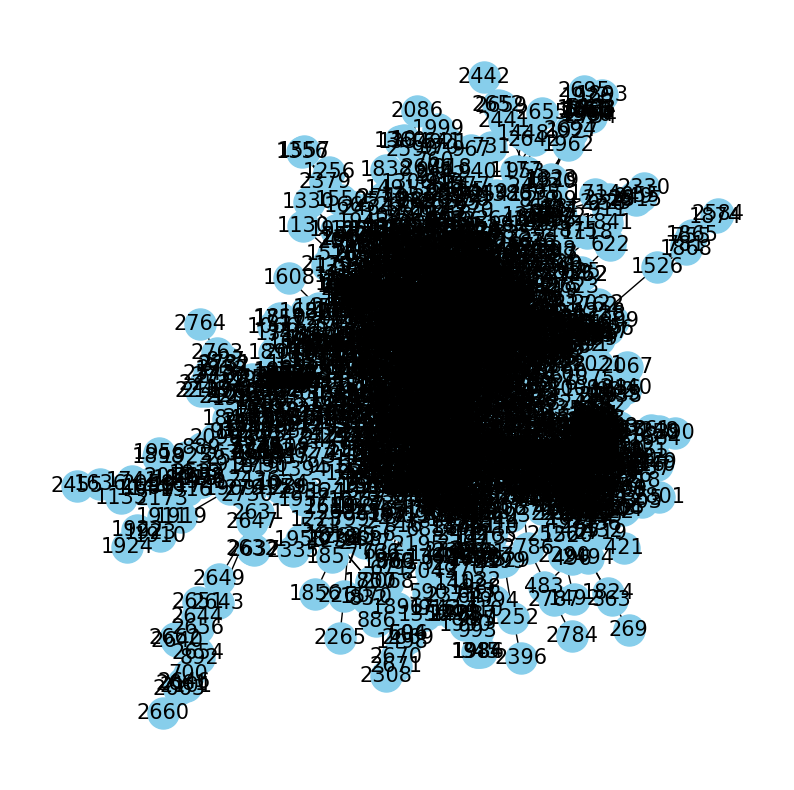

(2810, 2810)


In [9]:
from torch_geometric.utils import to_networkx
import networkx as nx

adj_numpy = graph.adj_matrix.toarray()
y_numpy = graph.labels

# Convert numpy adjacency matrix to networkx graph
G = nx.from_numpy_array(adj_numpy)

#G = to_networkx(graph.adj_matrix.toarray(), to_undirected=True)
plt.figure(figsize=(10, 10))
plt.axis('off')
nx.draw(G, with_labels=True, node_color='skyblue', node_size=500, font_size=15)
plt.show()
print(adj_numpy.shape)

In [10]:
print(adj_numpy.shape)
print(y_numpy.shape)

(2810, 2810)
(2810,)


In [11]:
edge_idx = torch.LongTensor(np.stack(graph.adj_matrix.nonzero()))#.cuda()
attr_idx = torch.LongTensor(np.stack(graph.attr_matrix.nonzero()))#.cuda()

## 2. Evaluation

For evaluation, we use the locally stored models. Similarly to training, we provide a script that runs the attacks for different seeds for all pretrained models. For all experiments, please check out the [config](https://github.com/sigeisler/robustness_of_gnns_at_scale/tree/main/config) folder.

### 2.1 Local PR-BCD Attack with grid_radii initialization
We provide an example for a `local PR-BCD` attack on the `Vanilla GCN` model trained previously by passing the desired configuration in [experiments/experiment_local_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_local_attack_direct.py#L68).

In [18]:
local_prbcd_statistics_cert = experiment_local_attack_direct.run(
    data_dir = './data',
    dataset = 'cora_ml',
    attack = 'LocalPRBCD',
    attack_params = dict(
        ppr_cache_params = dict(
            data_artifact_dir = 'cache',
            data_storage_type = 'ppr'),
        #epochs = 500, # -> way too high for my setup, use 40-100
        epochs = 50,
        fine_tune_epochs = 100, #this may have to be adjusted to epochs
        search_space_size = 100, #is here the same varibale error as in global_attack ?
        block_size = 100,
        ppr_recalc_at_end = True,
        loss_type = 'Margin',
        lr_factor = 0.05),
    nodes = None,
    nodes_topk = 5,
    seed=0,
    epsilons = [1],
    min_node_degree = None,
    binary_attr = False,
    make_undirected = True,
    artifact_dir = 'cache',
    model_label = 'Vanilla GCN',
    model_storage_type = 'demo',
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    debug_level = "info",
    grid_radii=None, #grid_radii still in here
    use_cert=True,
)

[11/17/25 15:01:09] INFO     {'dataset': 'cora_ml', 'attack': 'LocalPRBCD', 'attack_params':           ]8;id=678763;file://E:\Masterarbeit\ProjectCombined\experiments\common.py\common.py]8;;\:]8;id=133468;file://E:\Masterarbeit\ProjectCombined\experiments\common.py#38\38]8;;\
                             {'ppr_cache_params': {'data_artifact_dir': 'cache', 'data_storage_type':              
                             'ppr'}, 'epochs': 50, 'fine_tune_epochs': 100, 'search_space_size': 100,              
                             'block_size': 100, 'ppr_recalc_at_end': True, 'loss_type': 'Margin',                  
                             'lr_factor': 0.05}, 'epsilons': [1], 'make_undirected': True,                         
                             'binary_attr': False, 'seed': 0, 'artifact_dir': 'cache',                             
                             'pert_adj_storage_type': None, 'pert_attr_storage_type': None,                        
                             'model_label': 'Vanilla GCN', 'model_storage_type': 'demo', 'device':                 
                             'cpu', 'data_device': 'cpu'}                                                          

                    INFO     Lock 2028675962896 acquired on cache\demo.json.lock                    ]8;id=850289;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=265552;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2028675962896 released on cache\demo.json.lock                    ]8;id=693517;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=387396;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Found 1 models with label 'Vanilla GCN' to       ]8;id=183564;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=992160;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py#141\141]8;;\
                             attack.                                                                               

                    INFO     Sample Attack Nodes for model with accuracy 0.8352                       ]8;id=803450;file://E:\Masterarbeit\ProjectCombined\experiments\common.py\common.py]8;;\:]8;id=216003;file://E:\Masterarbeit\ProjectCombined\experiments\common.py#187\187]8;;\

...

                    ERROR    missing a required argument: 'graph'             ]8;id=100718;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=307695;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py#188\188]8;;\
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "E:\Masterarbeit\ProjectCombined\experiments\exp                                      
                             eriment_local_attack_direct.py", line 186, in                                         
                             run                                                                                   
                                 adversary.attack(n_perturbations,                                                 
                             node_idx=node, grid_radii=grid_radii)                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 1031, in wrapper                                        
                                 memo = _CallMemo(python_func, _localns,                                           
                             args=args, kwargs=kwargs)                                                             
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^^^^^^^^^^^^^^^^^^                                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 198, in __init__                                        
                                 self.arguments = signature.bind(*args,                                            
                             **kwargs).arguments                                                                   
                                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^                                                                                  
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3195, in bind                                                                    
                                 return self._bind(args, kwargs)                                                   
                                        ^^^^^^^^^^^^^^^^^^^^^^^^                                                   
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3110, in _bind                                                                   
                                 raise TypeError(msg) from None                                                    
                             TypeError: missing a required argument: 'graph'                                       

                    ERROR    Failed to attack model 'Vanilla GCN' using       ]8;id=100089;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=32699;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py#189\189]8;;\
                             LocalPRBCD with eps 1 at node 1707.                                                   

                    ERROR    missing a required argument: 'graph'             ]8;id=323580;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=273935;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py#188\188]8;;\
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "E:\Masterarbeit\ProjectCombined\experiments\exp                                      
                             eriment_local_attack_direct.py", line 186, in                                         
                             run                                                                                   
                                 adversary.attack(n_perturbations,                                                 
                             node_idx=node, grid_radii=grid_radii)                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 1031, in wrapper                                        
                                 memo = _CallMemo(python_func, _localns,                                           
                             args=args, kwargs=kwargs)                                                             
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^^^^^^^^^^^^^^^^^^                                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 198, in __init__                                        
                                 self.arguments = signature.bind(*args,                                            
                             **kwargs).arguments                                                                   
                                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^                                                                                  
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3195, in bind                                                                    
                                 return self._bind(args, kwargs)                                                   
                                        ^^^^^^^^^^^^^^^^^^^^^^^^                                                   
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3110, in _bind                                                                   
                                 raise TypeError(msg) from None                                                    
                             TypeError: missing a required argument: 'graph'                                       

                    ERROR    Failed to attack model 'Vanilla GCN' using       ]8;id=945931;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=941876;file://E:\Masterarbeit\ProjectCombined\experiments\experiment_local_attack_direct.py#189\189]8;;\
                             LocalPRBCD with eps 1 at node 834.                                                    

AssertionError: 

In [ ]:
n_change = 0
for node in local_prbcd_statistics_cert['results']:
    if node['margin'] < 0:
        n_change += 1
flipped_ratio_cert =  n_change / len(local_prbcd_statistics_cert['results'])
print(f'Percentage of changed node predictions for init with cert : {100*flipped_ratio_cert:.2f}%')

### 2.1.1 Local PR-BCD Attack without grid_radii initialization
We provide an example for a `local PR-BCD` attack on the `Vanilla GCN` model trained previously by passing the desired configuration in [experiments/experiment_local_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_local_attack_direct.py#L68).

In [ ]:
local_prbcd_statistics = experiment_local_attack_direct.run(
    data_dir = './data',
    dataset = 'cora_ml',
    attack = 'LocalPRBCD',
    attack_params = dict(
        ppr_cache_params = dict(
            data_artifact_dir = 'cache',
            data_storage_type = 'ppr'),
        #epochs = 500, # -> way too high for my setup, use 40-100
        epochs = 50,
        fine_tune_epochs = 100,
        search_space_size = 100,
        block_size = 100,
        ppr_recalc_at_end = True,
        loss_type = 'Margin',
        lr_factor = 0.05),
    nodes = None,
    nodes_topk = 5,
    seed=0,
    epsilons = [1],
    min_node_degree = None,
    binary_attr = False,
    make_undirected = True,
    artifact_dir = 'cache',
    model_label = 'Vanilla GCN',
    model_storage_type = 'demo',
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    debug_level = "info",
    grid_radii=None #grid_radii still in here
)

In [ ]:
n_change = 0
for node in local_prbcd_statistics['results']:
    if node['margin'] < 0:
        n_change += 1
flipped_ratio =  n_change / len(local_prbcd_statistics['results'])
print(f'Percentage of changed node predictions : {100*flipped_ratio:.2f}%')

In [ ]:
n_change = 0
for node in local_prbcd_statistics_cert['results']:
    if node['margin'] < 0:
        n_change += 1
flipped_ratio_cert =  n_change / len(local_prbcd_statistics_cert['results'])
print(f'Percentage of changed node predictions for init with cert : {100*flipped_ratio_cert:.2f}%')

### 2.2 Global PR-BCD Attack with Cert

Now let's do the same with a non-local `PR-BCD` attack. For this, we use [experiments/experiment_global_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_global_attack_direct.py#L63).

In [18]:
from DeleteCache import delete_pert_files_and_folders
from IPython.display import clear_output
from timeit import default_timer as timer
from itertools import zip_longest
import csv
import os
import time

# =========================
# Output locations (point this at your plotting folder)
# =========================
# If your plotting reads from config.TEST_DATA_DIR, set OUT_DIR = config.TEST_DATA_DIR
OUT_DIR = "."   # <- change to your plotting folder if needed
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# CSV schemas
# =========================
summary_header = [
    "run_id", "use_cert", "accuracy", "time",
    "epoch", "fine_tune_epoch", "epsilon", "block_size", "semi"
]
epochs_header  = [
    "run_id", "use_cert", "epoch_idx", "accuracy", "loss",
    "nonzero_weights", "prob_mass_update", "prob_mass_projected",
    "epsilon", "block_size", "semi", "total_epochs", "fine_tune_epochs"
]

# Whether to delete existing files with old headers (only applies if filenames collide)
RESET_CSVS = False  # set True once to delete existing files with old headers

def _open_writer(path, fieldnames):
    """
    Open a DictWriter that guarantees the header matches `fieldnames`.
    Raises if an existing file has a different header.
    """
    file_exists = os.path.isfile(path)
    if file_exists:
        with open(path, newline="") as r:
            reader = csv.reader(r)
            on_disk = next(reader, None)
        if on_disk != fieldnames:
            raise RuntimeError(
                f"Header mismatch in {path}.\n"
                f"Found:  {on_disk}\n"
                f"Expect: {fieldnames}\n"
                f"Rename/delete the file or set RESET_CSVS=True once."
            )
    f = open(path, "a", newline="")
    w = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        w.writeheader()
    return f, w

# =========================
# Sweep config
# =========================
results_global_prbcd_cert = []

partly_drawn_nodes = [True]
block_sizes       = [5000]
epsilons          = [0.25]
epochs_list       = [50]
fine_tune_epochs  = [25]
use_certificate   = ["accuracy_drop_selector","none"]
accuracy_drop_selector_mode = ["k_action_individual"] # "k_hop", "one_sample", "k_action"

# =========================
# Param-tagged CSV filenames (+ short timestamp)
# =========================
def _slug(x):
    # make values filename-safe: 0.25 -> 0p25, spaces removed
    s = str(x)
    return s.replace(" ", "").replace(".", "p").replace("/", "_").replace("\\", "_").replace(":", "-")

def _join_slug(seq):
    # join a list into a compact token like a+b+c
    return "+".join(_slug(v) for v in seq)

# Small timestamp (YYMMDD-HHMMSS)
STAMP = time.strftime("%y%m%d-%H%M%S")

# Build a compact, informative parameter tag
PARAM_TAG = (
    f"bs{_join_slug(block_sizes)}"
    f"__eps{_join_slug(epsilons)}"
    f"__ep{_join_slug(epochs_list)}"
    f"__ft{_join_slug(fine_tune_epochs)}"
    f"__cert{_join_slug(use_certificate)}"
)

SUMMARY_CSV = os.path.join(OUT_DIR, f"global_prbcd_cert_results__{PARAM_TAG}__{STAMP}.csv")
EPOCHS_CSV  = os.path.join(OUT_DIR, f"global_prbcd_cert_epochs__{PARAM_TAG}__{STAMP}.csv")

# Optionally clear existing CSVs if names collide (rare due to timestamp)
if RESET_CSVS:
    for p in (SUMMARY_CSV, EPOCHS_CSV):
        if os.path.exists(p):
            os.remove(p)

# Touch files / validate headers now
_open_writer(SUMMARY_CSV, summary_header)[0].close()
_open_writer(EPOCHS_CSV,  epochs_header)[0].close()

# =========================
# Derived loop count
# =========================
base_combinations = (
    len(partly_drawn_nodes)
    * len(block_sizes)
    * len(epsilons)
    * len(epochs_list)
    * len(fine_tune_epochs)
)

has_ads = "accuracy_drop_selector" in use_certificate
num_other_certs = len(use_certificate) - (1 if has_ads else 0)

number_loops = base_combinations * (
    num_other_certs + (len(accuracy_drop_selector_mode) if has_ads else 0)
)
loop = 1

edge_idx = torch.LongTensor(np.stack(graph.adj_matrix.nonzero()))
attr_idx = torch.LongTensor(np.stack(graph.attr_matrix.nonzero()))

for semi in partly_drawn_nodes:
    for block_size in block_sizes:
        for epsilon in epsilons:
            for total_epochs in epochs_list:
                for ft_epochs in fine_tune_epochs:
                    for use_cert in use_certificate:

                        # choose modes only for accuracy_drop_selector
                        if use_cert == "accuracy_drop_selector":
                            modes = accuracy_drop_selector_mode
                        else:
                            modes = [None]

                        for ads_mode in modes:
                            # Decorated label for CSV / run_id
                            if use_cert == "accuracy_drop_selector" and ads_mode is not None:
                                use_cert_label = f"{use_cert}_{ads_mode}"
                            else:
                                use_cert_label = use_cert

                            # Unique ID per run (include label)
                            run_id = (
                                f"{int(time.time())}-"
                                f"{use_cert_label}-"
                                f"eps{epsilon}-bs{block_size}-"
                                f"semi{int(semi)}-ep{total_epochs}-ft{ft_epochs}"
                            )

                            delete_pert_files_and_folders(
                                cache_dir="cache",
                                pert_adj_storage_type="evasion_global_adj",
                                pert_attr_storage_type="evasion_global_attr"
                            )
                            print("loop", loop, "of", number_loops)
                            loop += 1

                            attack_params = dict(
                                epochs=total_epochs,
                                fine_tune_epochs=ft_epochs,
                                keep_heuristic="WeightOnly",
                                search_space_size=100_000,
                                block_size=block_size,
                                do_synchronize=True,
                                loss_type="tanhMargin",
                            )
                            # optional: pass mode into the attack
                            if use_cert == "accuracy_drop_selector" and ads_mode is not None:
                                attack_params["accuracy_drop_selector_mode"] = ads_mode

                            start = timer()
                            global_prbcd_statistics_cert = experiment_global_attack_direct.run(
                                ads_mode=ads_mode,
                                graph=graph,
                                data_dir='./data',
                                dataset='cora_ml',
                                attack='PRBCD',
                                attack_params=attack_params,
                                epsilons=[epsilon],
                                binary_attr=False,
                                make_undirected=True,
                                seed=0,
                                artifact_dir='cache',
                                pert_adj_storage_type='evasion_global_adj',
                                pert_attr_storage_type='evasion_global_attr',
                                model_label='Vanilla GCN',
                                model_storage_type='demo',
                                device="cpu",
                                data_device="cpu",
                                debug_level="info",
                                semi=semi,
                                use_cert=use_cert,
                            )
                            elapsed = timer() - start

                            # =========================
                            # Final-accuracy summary row
                            # =========================
                            final_acc = global_prbcd_statistics_cert["results"][0]["accuracy"]
                            f_sum, w_sum = _open_writer(SUMMARY_CSV, summary_header)
                            w_sum.writerow({
                                "run_id": run_id,
                                "use_cert": use_cert_label,
                                "accuracy": final_acc,
                                "time": elapsed,
                                "epoch": total_epochs,
                                "fine_tune_epoch": ft_epochs,
                                "epsilon": epsilon,
                                "block_size": block_size,
                                "semi": semi,
                            })
                            f_sum.close()

                            # =========================
                            # Per-epoch logging
                            # =========================
                            stats = (
                                global_prbcd_statistics_cert.get("attack_statistics")
                                or global_prbcd_statistics_cert.get("stats")
                                or global_prbcd_statistics_cert.get("attack_stats")
                            )

                            if stats:
                                def _to_py(seq):
                                    out = []
                                    for v in seq:
                                        try:
                                            out.append(float(v))
                                        except Exception:
                                            out.append(v)
                                    return out

                                acc_list  = _to_py(stats.get("accuracy", []))
                                loss_list = _to_py(stats.get("loss", []))
                                nnz_list  = _to_py(stats.get("nonzero_weights", []))
                                pmu_list  = _to_py(stats.get("probability_mass_update", []))
                                pmp_list  = _to_py(stats.get("probability_mass_projected", []))

                                f_ep, w_ep = _open_writer(EPOCHS_CSV, epochs_header)
                                for epoch_idx, acc, loss, nnz, pmu, pmp in zip_longest(
                                    range(len(acc_list)), acc_list, loss_list, nnz_list, pmu_list, pmp_list, fillvalue=""
                                ):
                                    w_ep.writerow({
                                        "run_id": run_id,
                                        "use_cert": use_cert_label,
                                        "epoch_idx": epoch_idx,  # 0 may be "pre-attack" entry
                                        "accuracy": acc,
                                        "loss": loss,
                                        "nonzero_weights": nnz,
                                        "prob_mass_update": pmu,
                                        "prob_mass_projected": pmp,
                                        "epsilon": epsilon,
                                        "block_size": block_size,
                                        "semi": semi,
                                        "total_epochs": total_epochs,
                                        "fine_tune_epochs": ft_epochs,
                                    })
                                f_ep.close()
                            else:
                                print("[warn] No attack_statistics found in result; per-epoch CSV skipped.")

                            # Optional: print gradient info if present
                            if "gradient" in global_prbcd_statistics_cert:
                                print(global_prbcd_statistics_cert["gradient"])

                            print("time:", elapsed)
                            print(use_cert_label + ":")
                            print(global_prbcd_statistics_cert)

                            results_global_prbcd_cert.append((
                                use_cert_label, "ACCURACY:", final_acc, "time:", elapsed, "semi:", semi
                            ))
                            clear_output(wait=True)

# Pretty print
def printItem(item):
    print(item)
    print("\n")

print("RESULTS")
[printItem(item) for item in results_global_prbcd_cert]

[None, None]

### 2.2.0 Pandas data analysis

#### 2.2.1 SelectorGNN Logs

Found 3 CSV files.

 Plotting: selector_gnn_ads-k_action_individual_k5000_kb10_drpmdacc_drp0.001_20260109_133809.csv


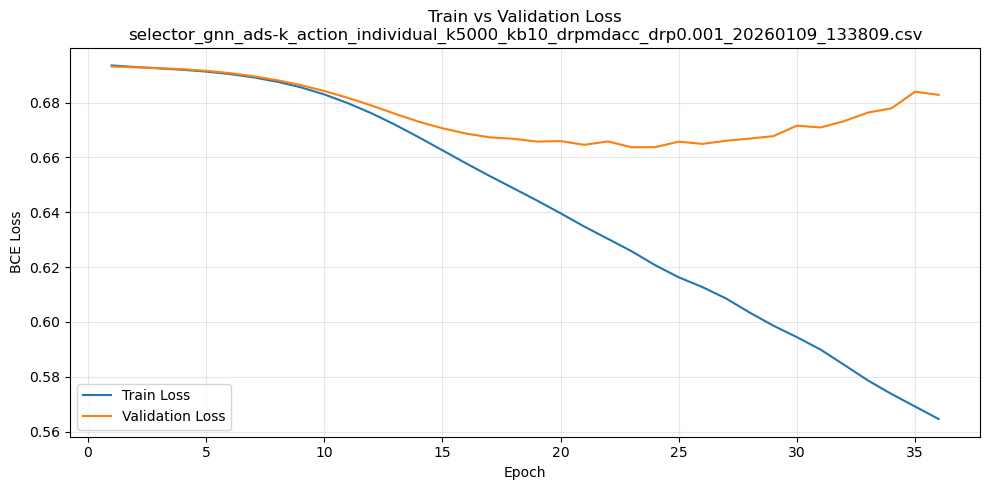

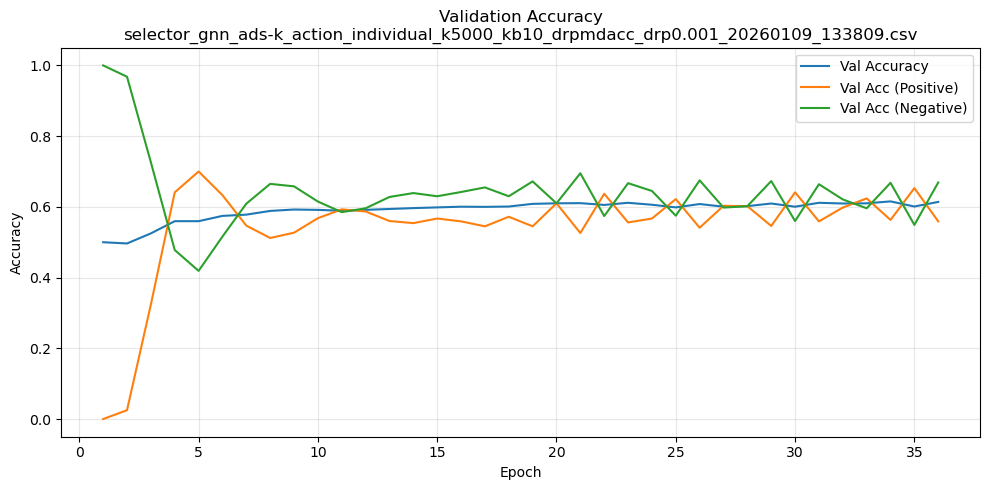

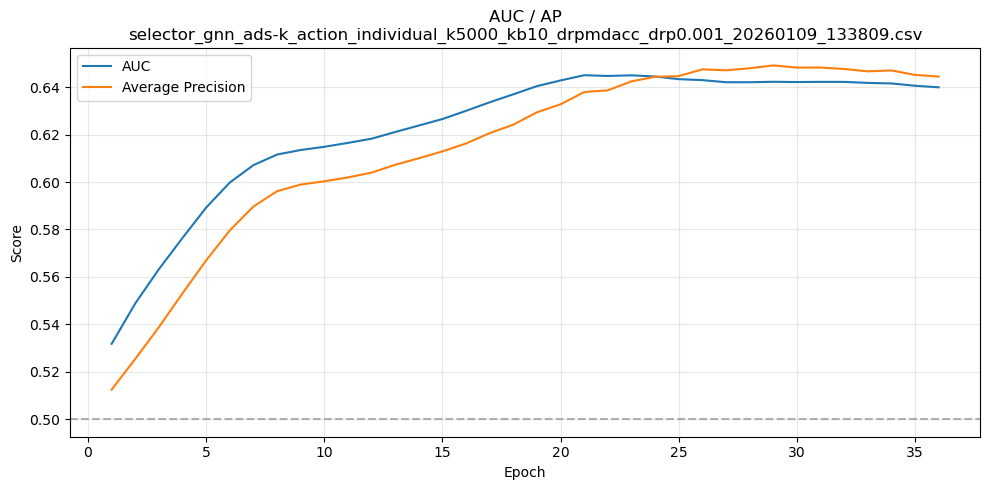

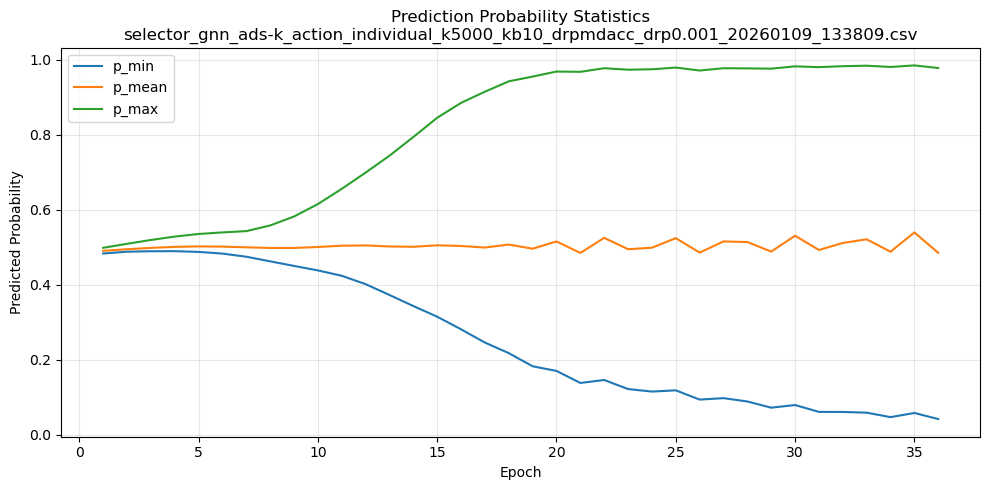

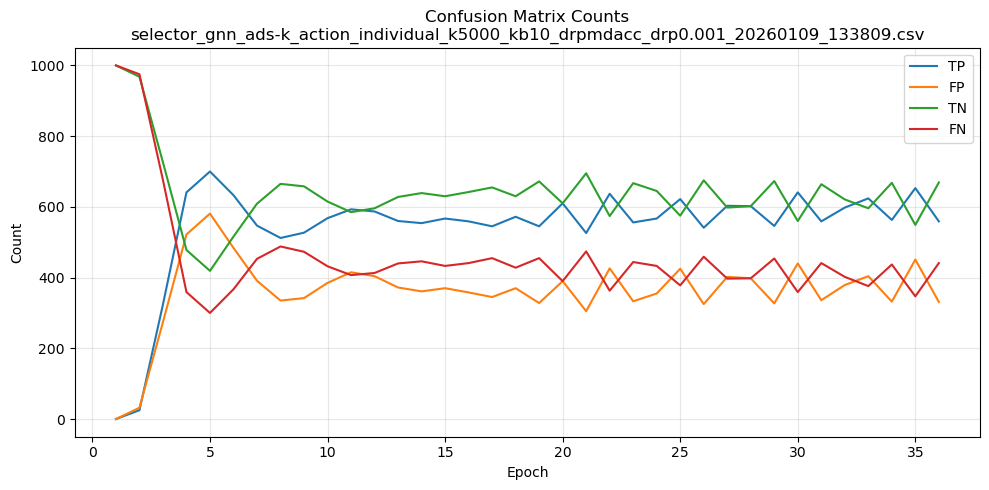

————————————————————————————————————————————————————————————
 Plotting: selector_gnn_ads-k_action_individual_k5000_kb10_drpmdacc_drp0.001_20260109_144037.csv


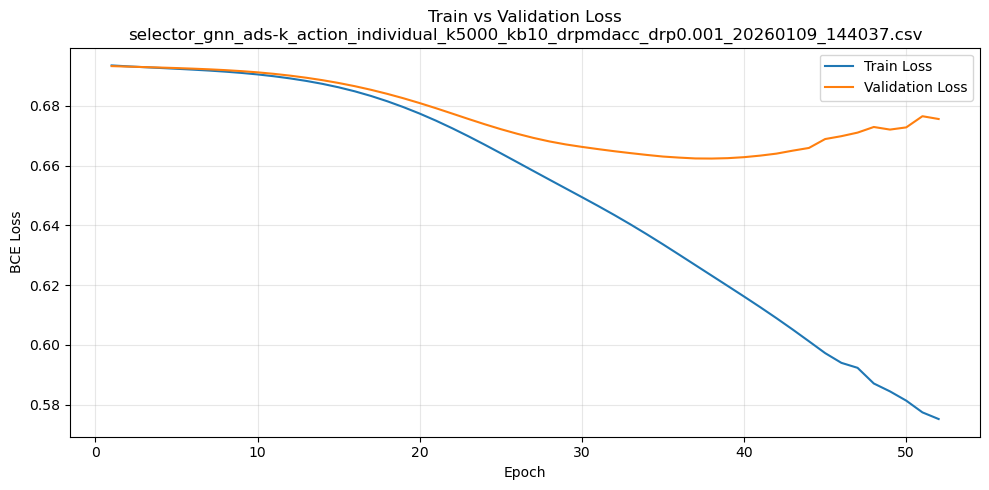

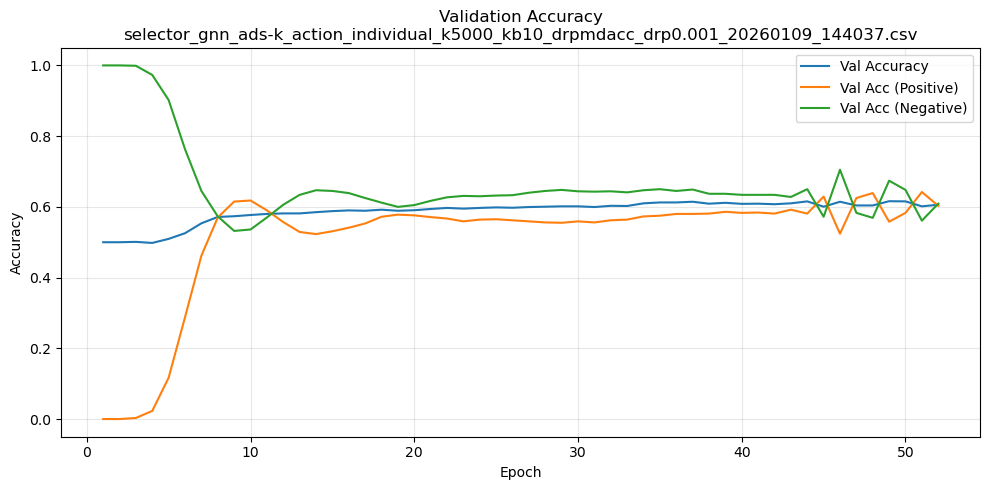

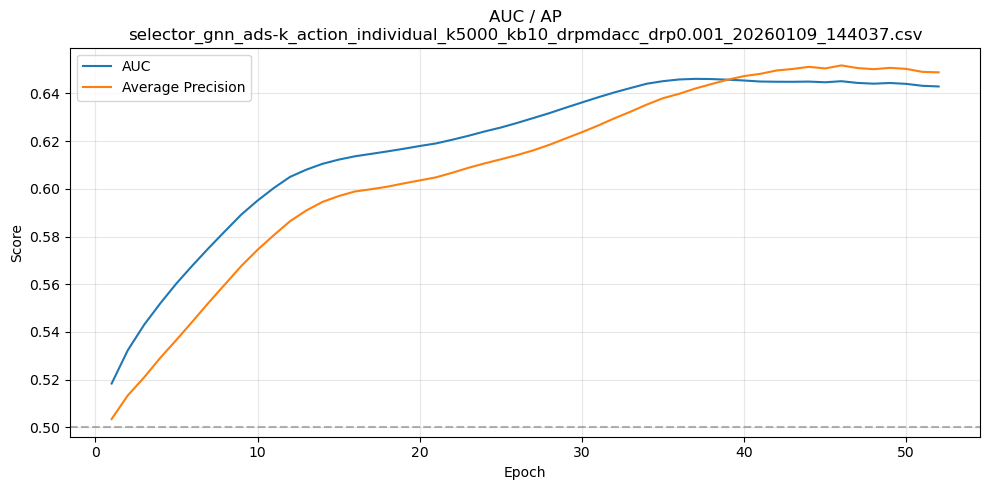

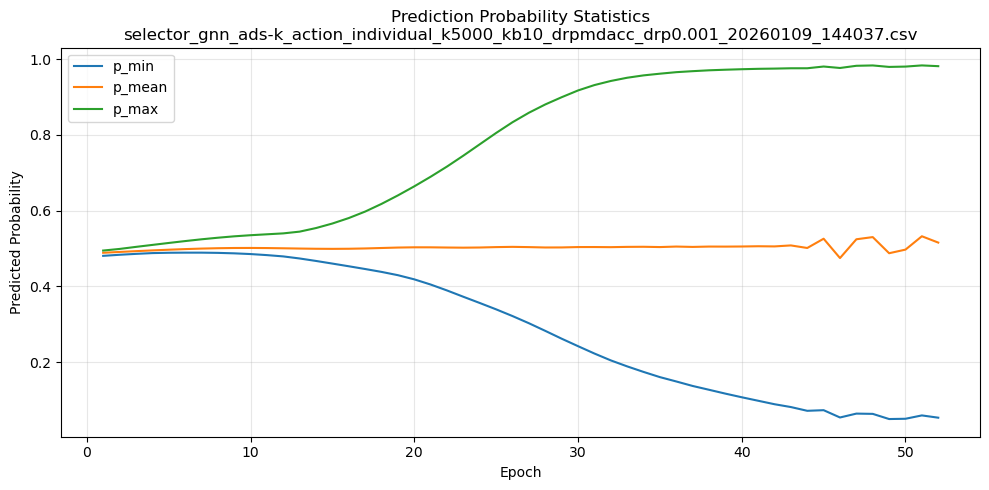

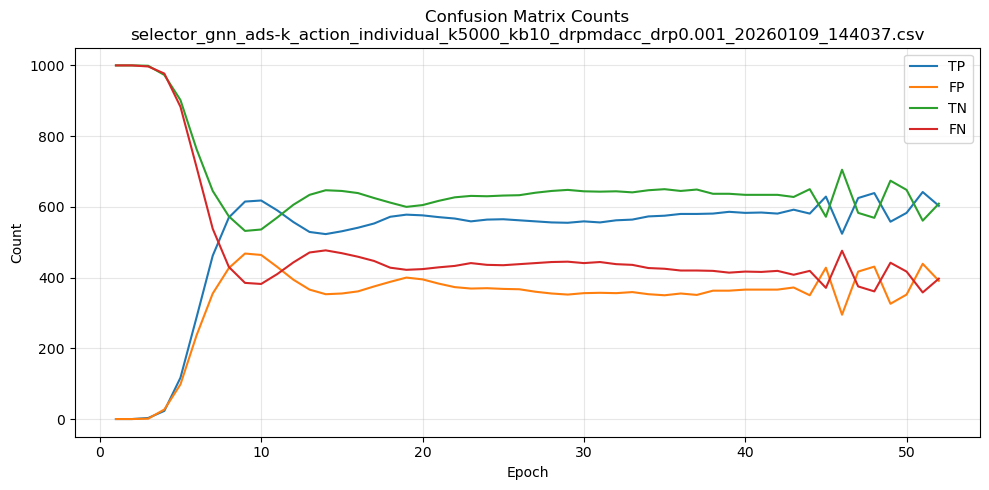

————————————————————————————————————————————————————————————
 Plotting: selector_gnn_ads-k_action_individual_k5000_kb10_drpmdloss_drp0.001_20260109_134047.csv


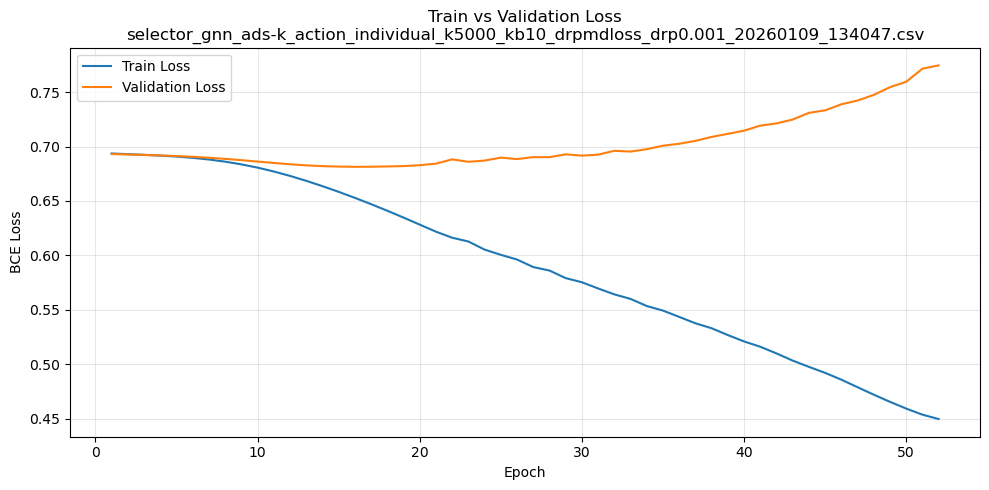

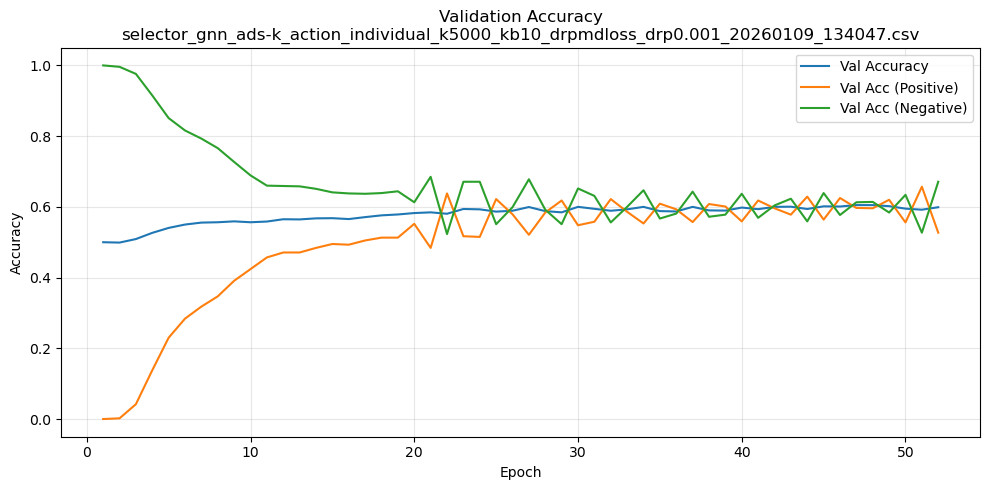

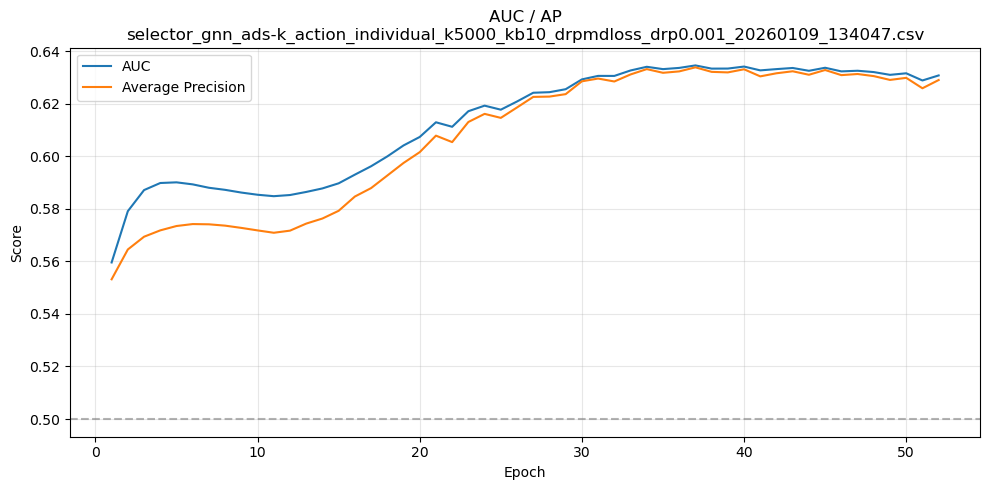

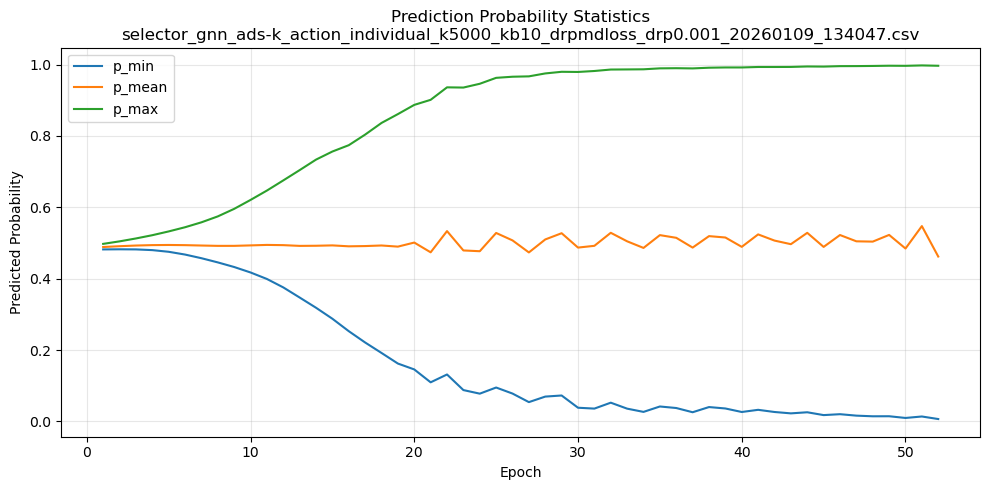

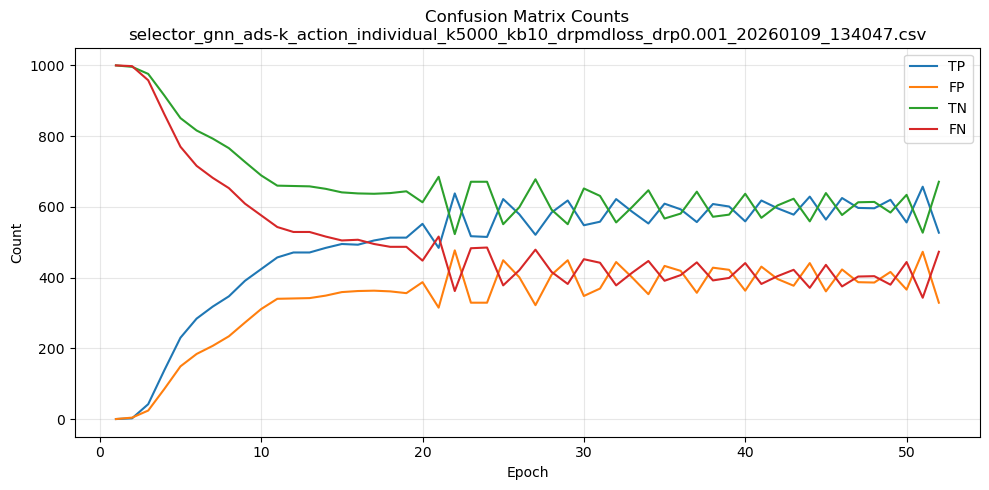

————————————————————————————————————————————————————————————


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Folder with SelectorGNN CSVs
# ===============================
csv_folder = "Plotting_Data/SelectorGNNLogs"

csv_files = sorted([
    os.path.join(csv_folder, f)
    for f in os.listdir(csv_folder)
    if f.endswith(".csv")
])

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {csv_folder}")

print(f"Found {len(csv_files)} CSV files.\n")


for csv_path in csv_files:
    print(f" Plotting: {os.path.basename(csv_path)}")

    df = pd.read_csv(csv_path)

    # --- basic cleanup ---
    if "epoch" not in df.columns:
        print(" Skipping (no 'epoch' column found)")
        continue

    df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce")
    df = df.dropna(subset=["epoch"])

    # ===============================
    # 1) Train vs Validation Loss
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.title(f"Train vs Validation Loss\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 2) Validation Accuracy (overall + per class)
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["val_acc"], label="Val Accuracy")
    plt.plot(df["epoch"], df["acc_pos"], label="Val Acc (Positive)")
    plt.plot(df["epoch"], df["acc_neg"], label="Val Acc (Negative)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Validation Accuracy\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 3) AUC & Average Precision
    # ===============================
    if "auc" in df.columns and "ap" in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df["epoch"], df["auc"], label="AUC")
        plt.plot(df["epoch"], df["ap"], label="Average Precision")
        plt.axhline(0.5, linestyle="--", color="gray", alpha=0.6)
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title(f"AUC / AP\n{os.path.basename(csv_path)}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ===============================
    # 4) Prediction probability stats
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["p_min"], label="p_min")
    plt.plot(df["epoch"], df["p_mean"], label="p_mean")
    plt.plot(df["epoch"], df["p_max"], label="p_max")
    plt.xlabel("Epoch")
    plt.ylabel("Predicted Probability")
    plt.title(f"Prediction Probability Statistics\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 5) Confusion matrix evolution
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["tp"], label="TP")
    plt.plot(df["epoch"], df["fp"], label="FP")
    plt.plot(df["epoch"], df["tn"], label="TN")
    plt.plot(df["epoch"], df["fn"], label="FN")
    plt.xlabel("Epoch")
    plt.ylabel("Count")
    plt.title(f"Confusion Matrix Counts\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 6) Gradient norm (optional)
    # ===============================
    if "grad_norm" in df.columns and df["grad_norm"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(df["epoch"], df["grad_norm"])
        plt.xlabel("Epoch")
        plt.ylabel("Gradient Norm")
        plt.title(f"Gradient Norm\n{os.path.basename(csv_path)}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    print("—" * 60)

#### 2.2.1 PRBCD Logs

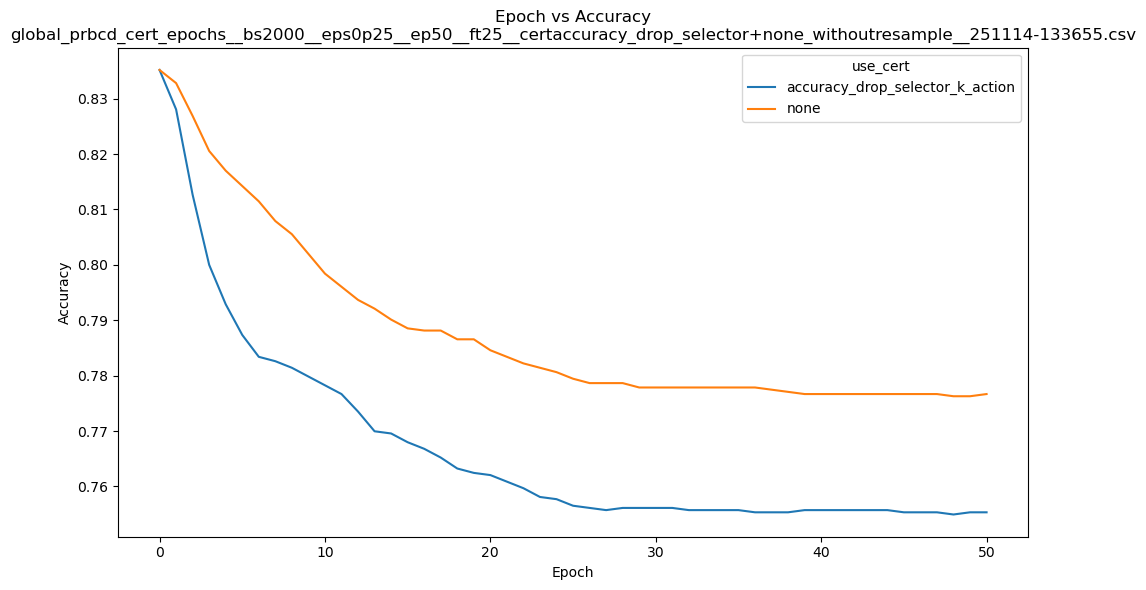

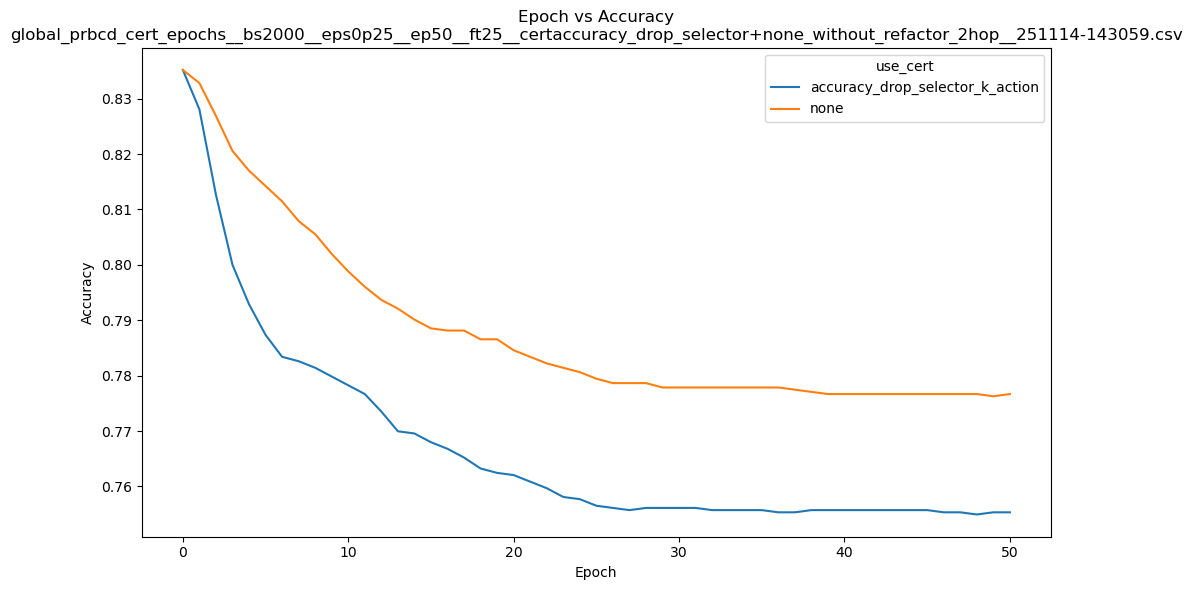

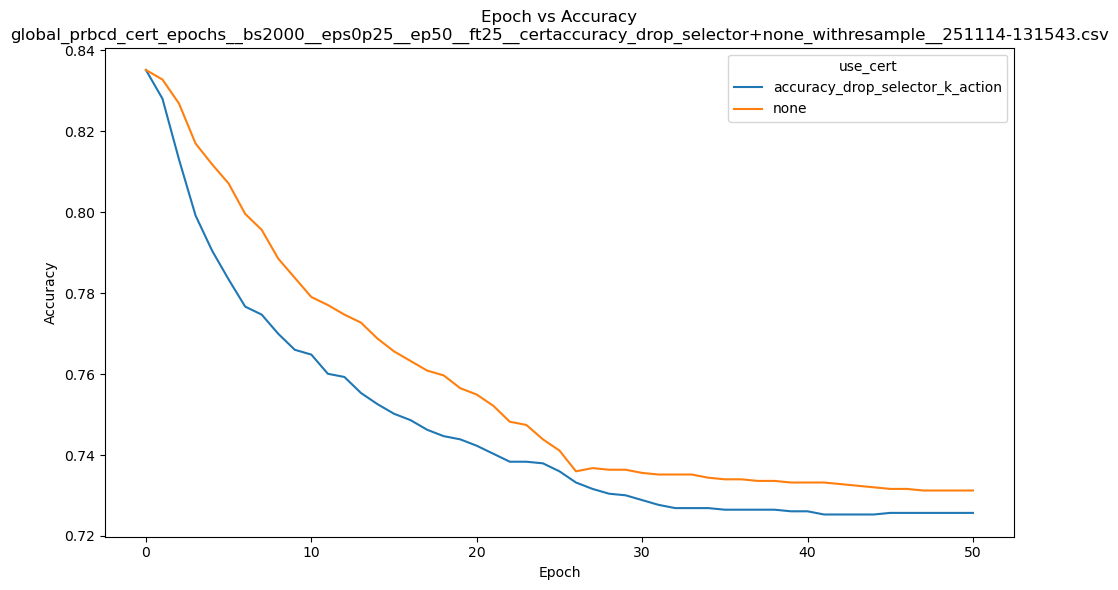

C:\Users\Schulz\AppData\Local\Temp\ipykernel_20040\1567914378.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="use_cert")


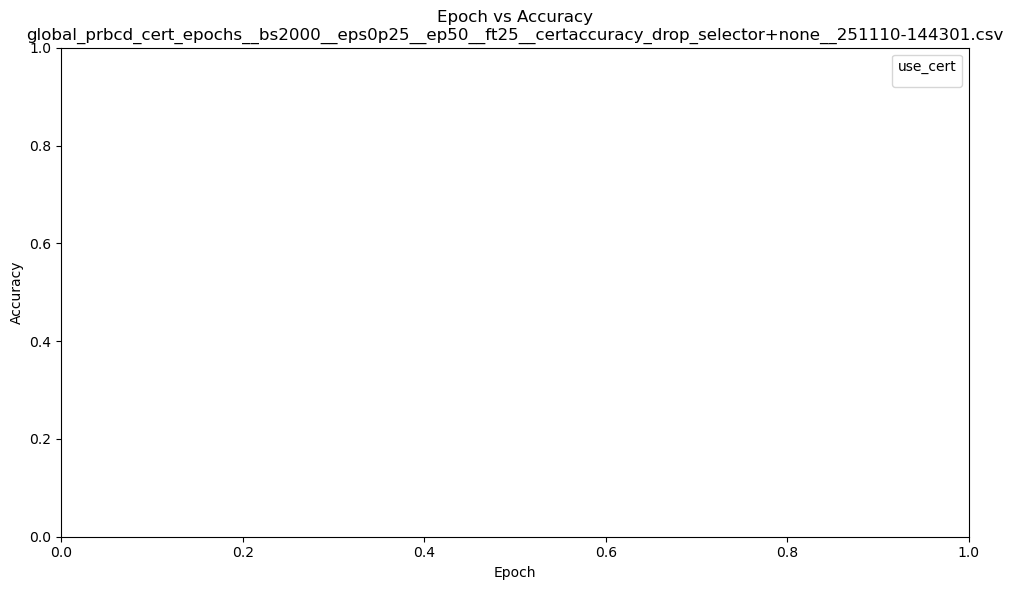

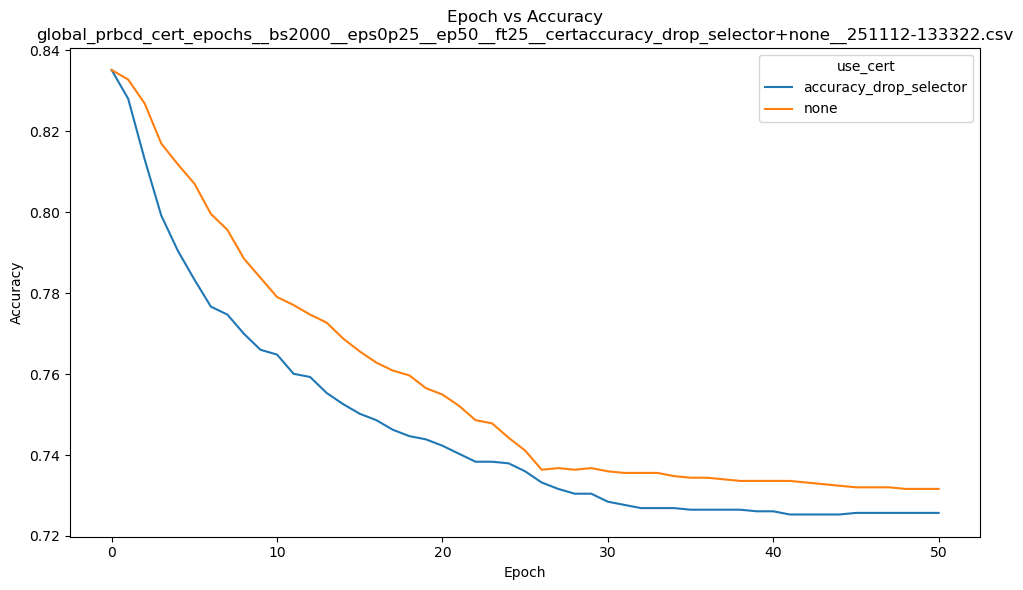

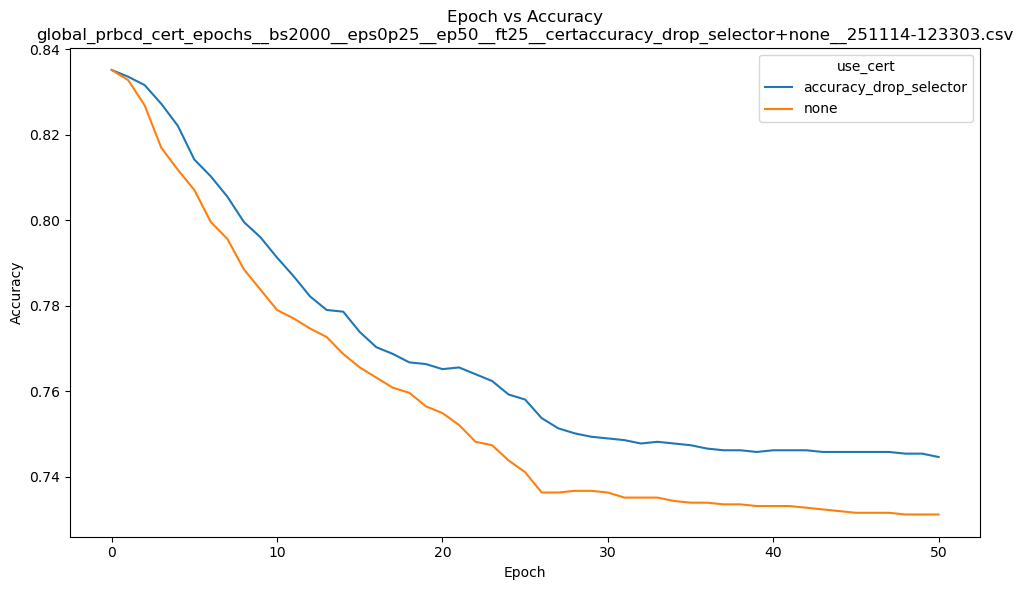

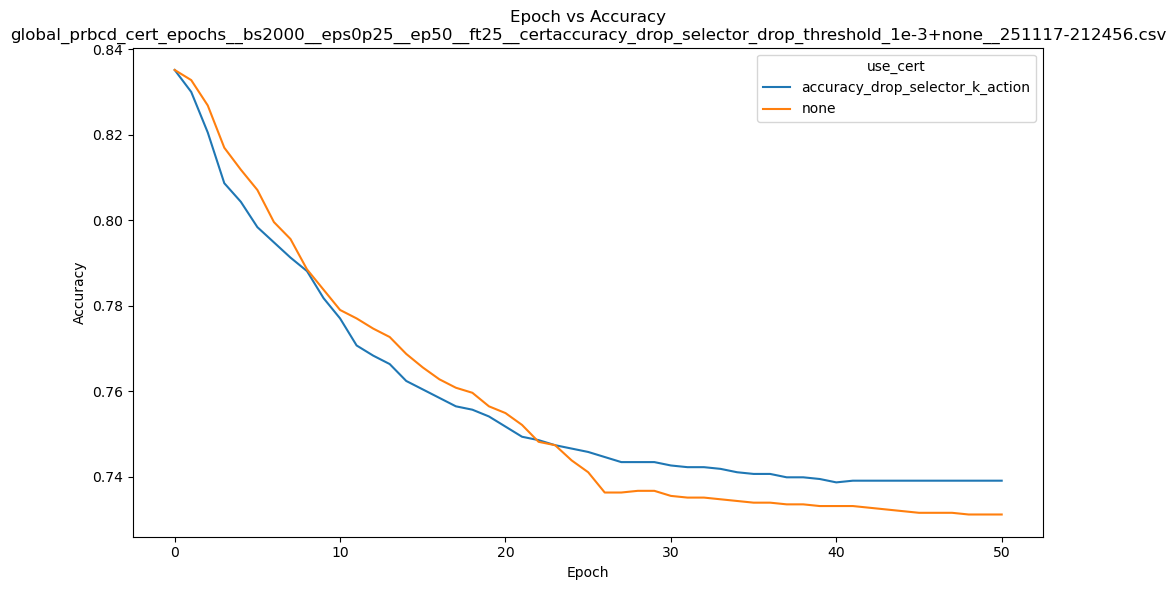

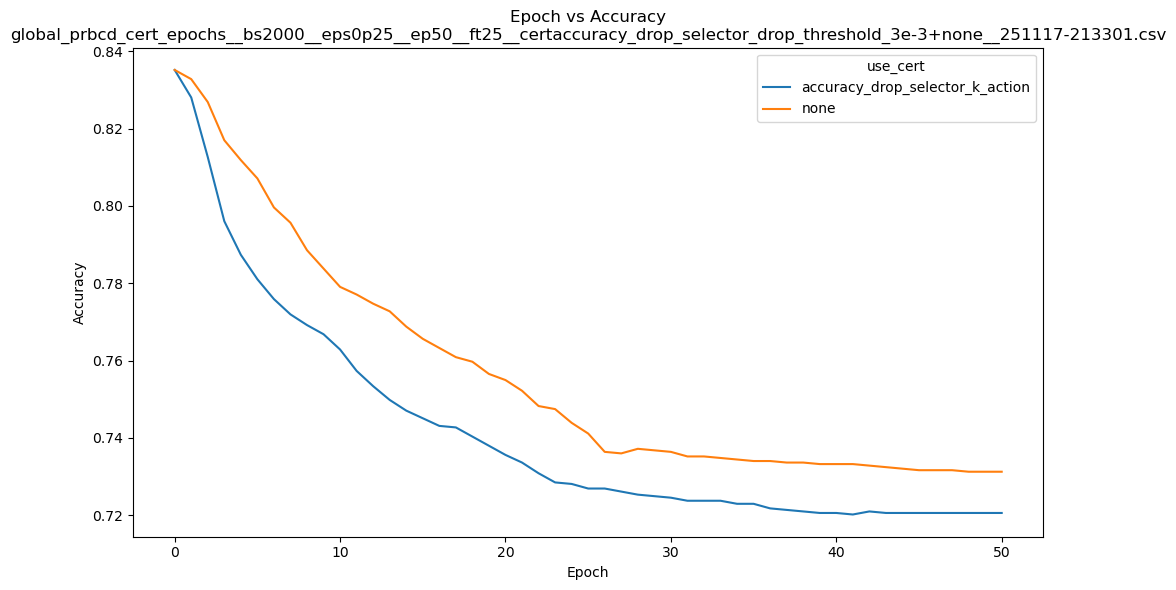

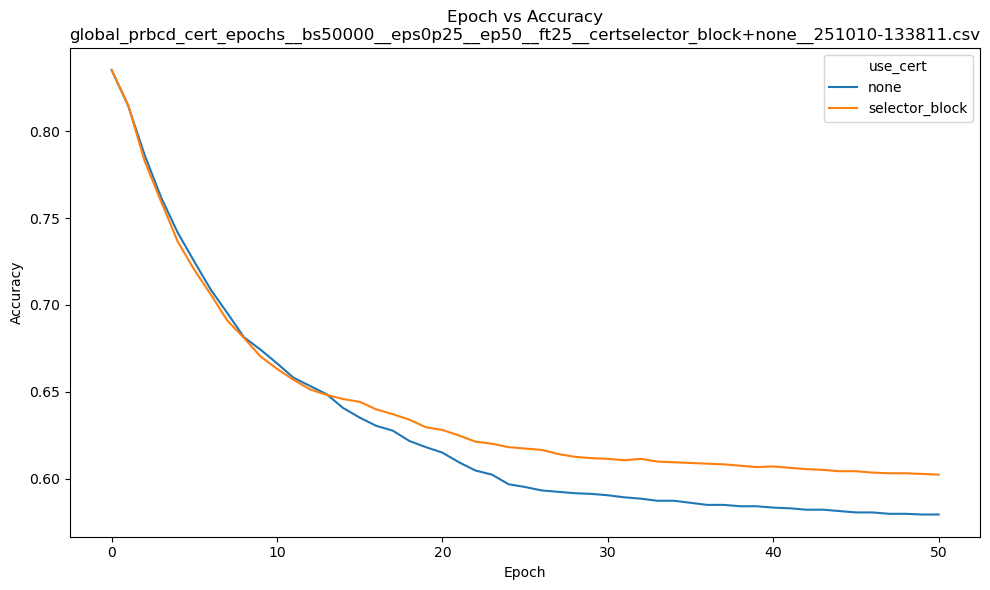

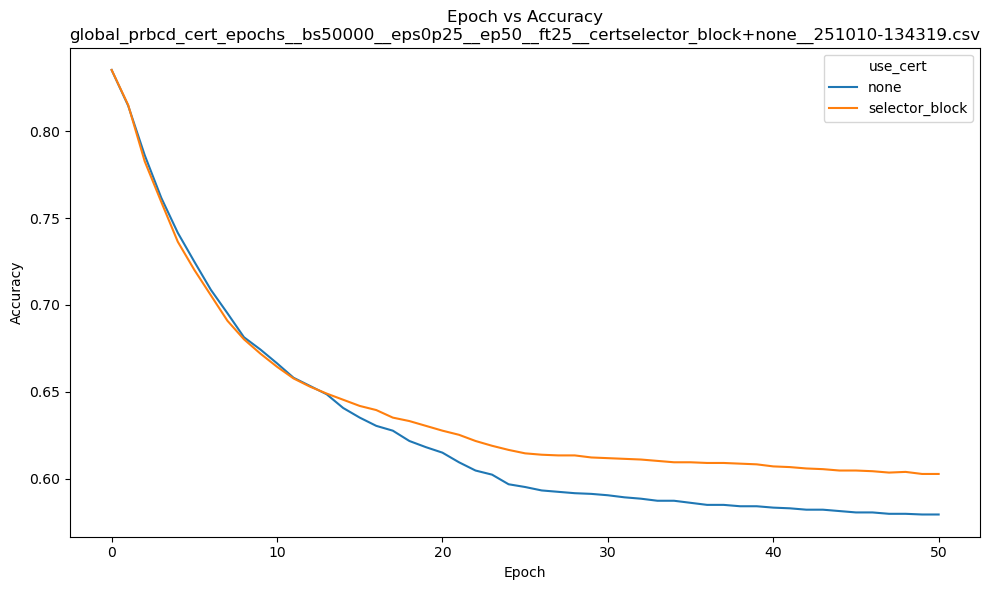

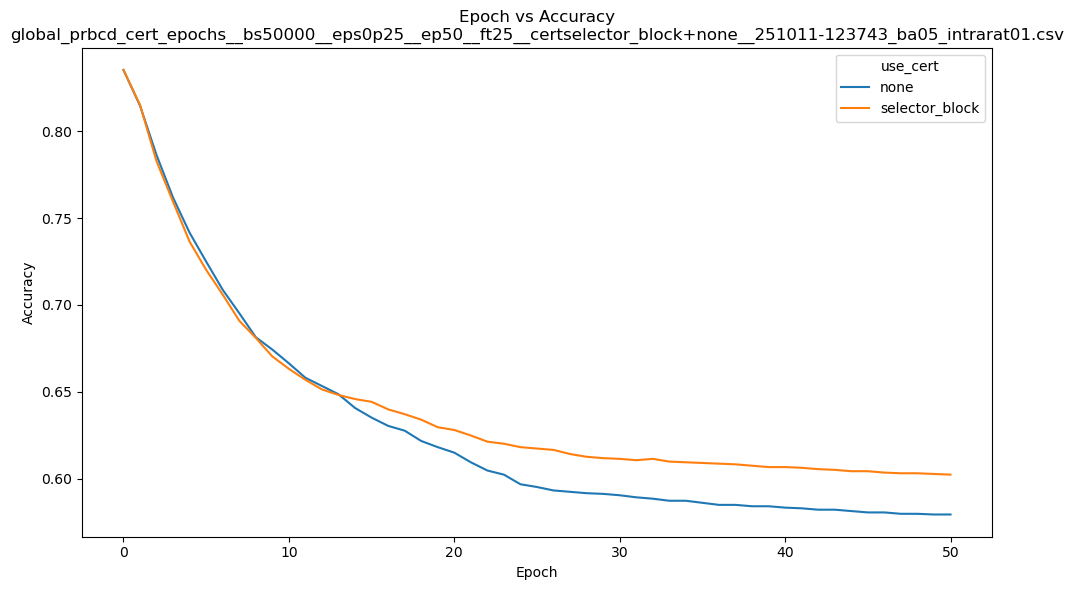

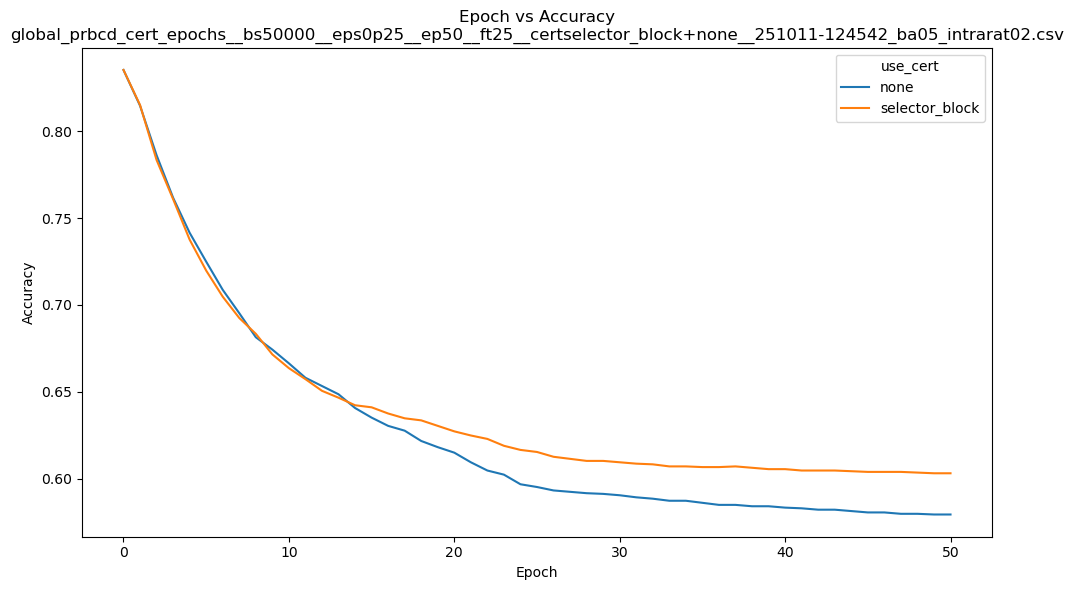

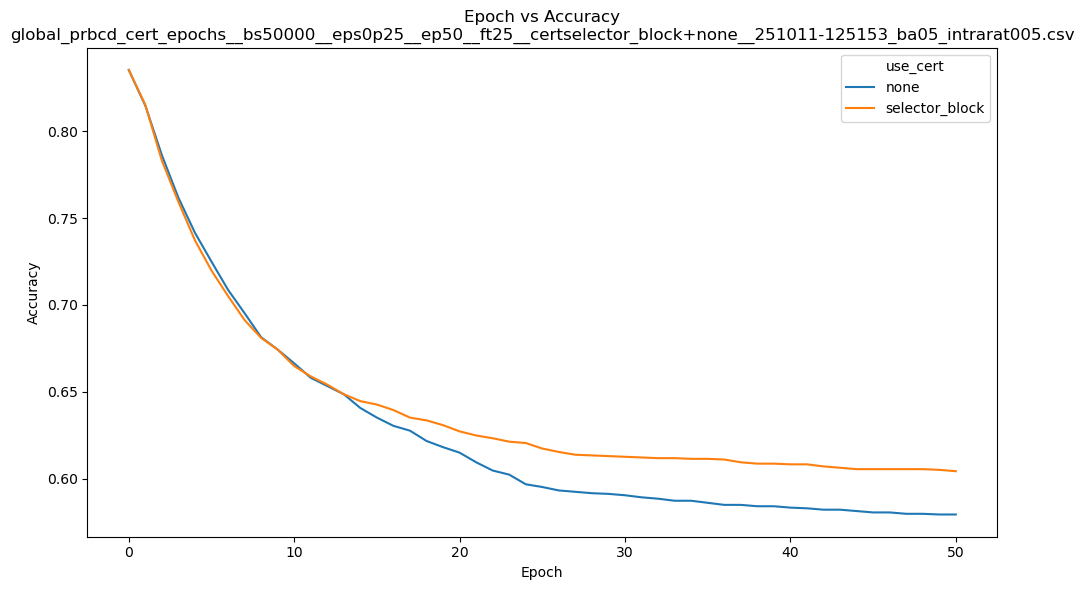

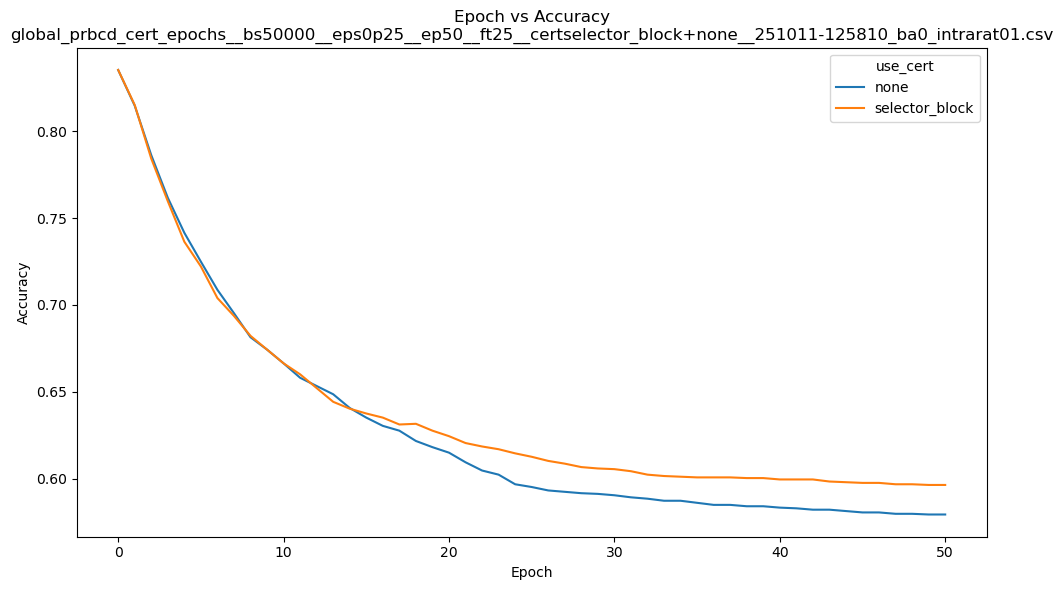

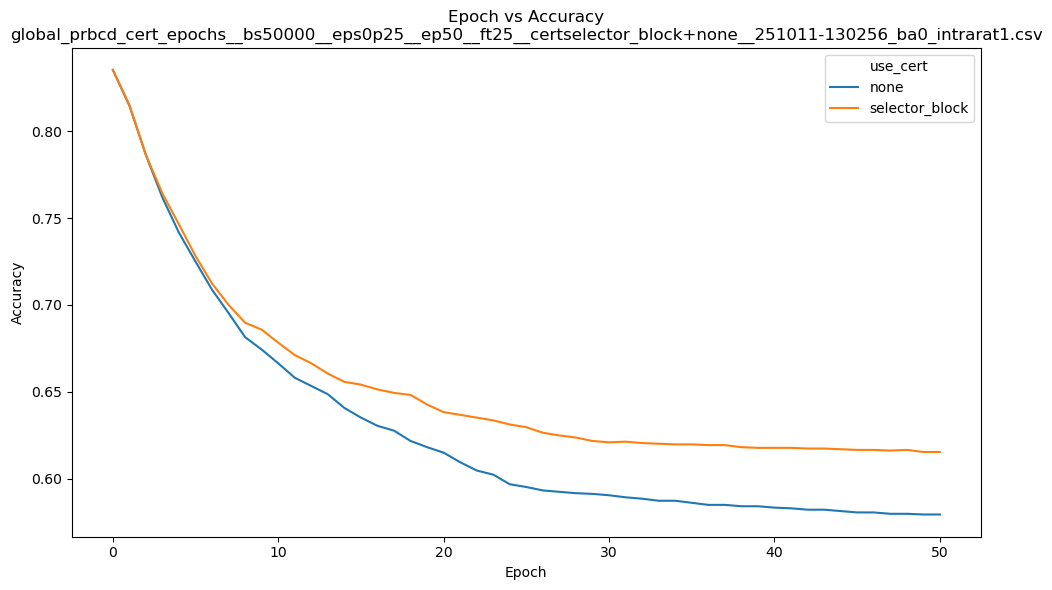

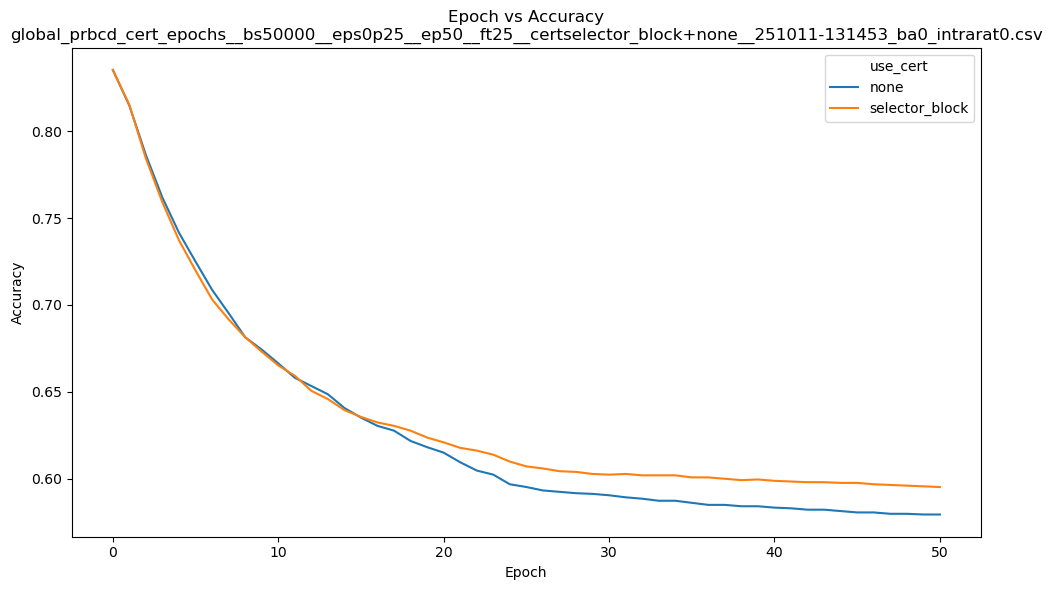

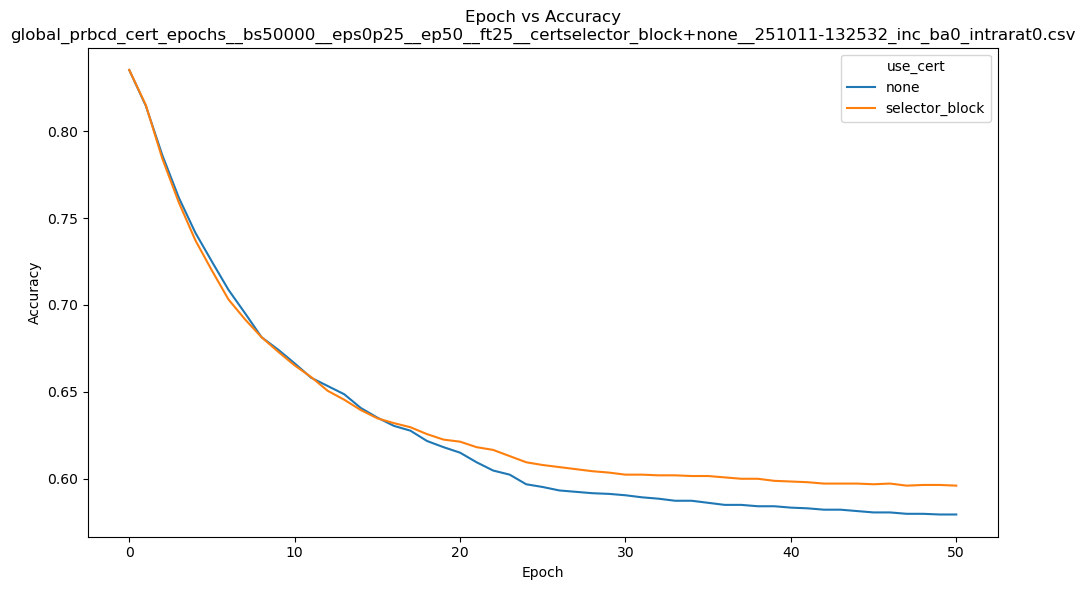

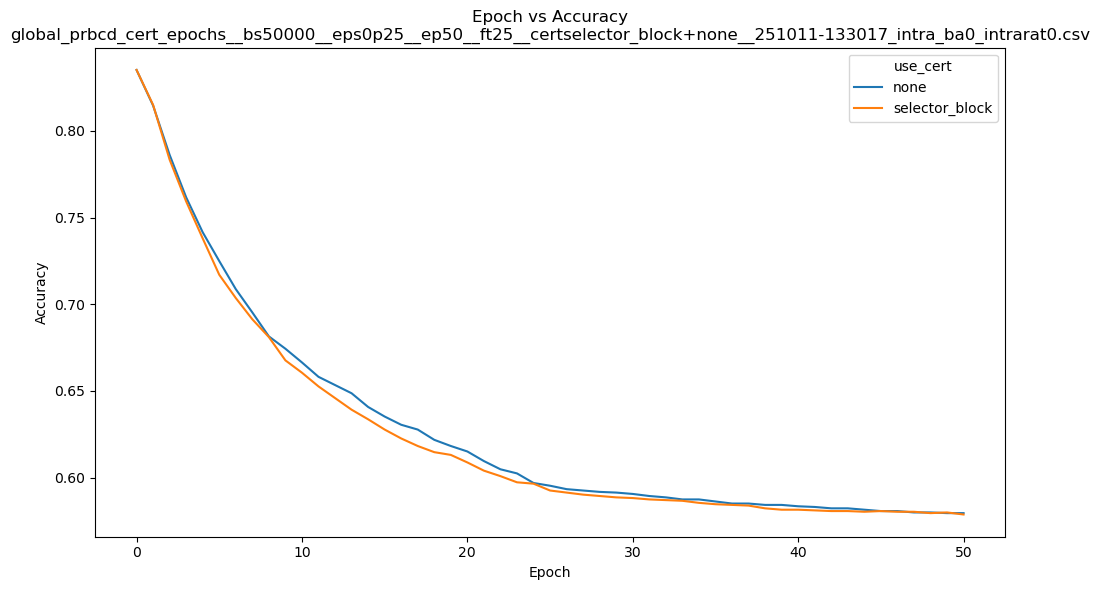

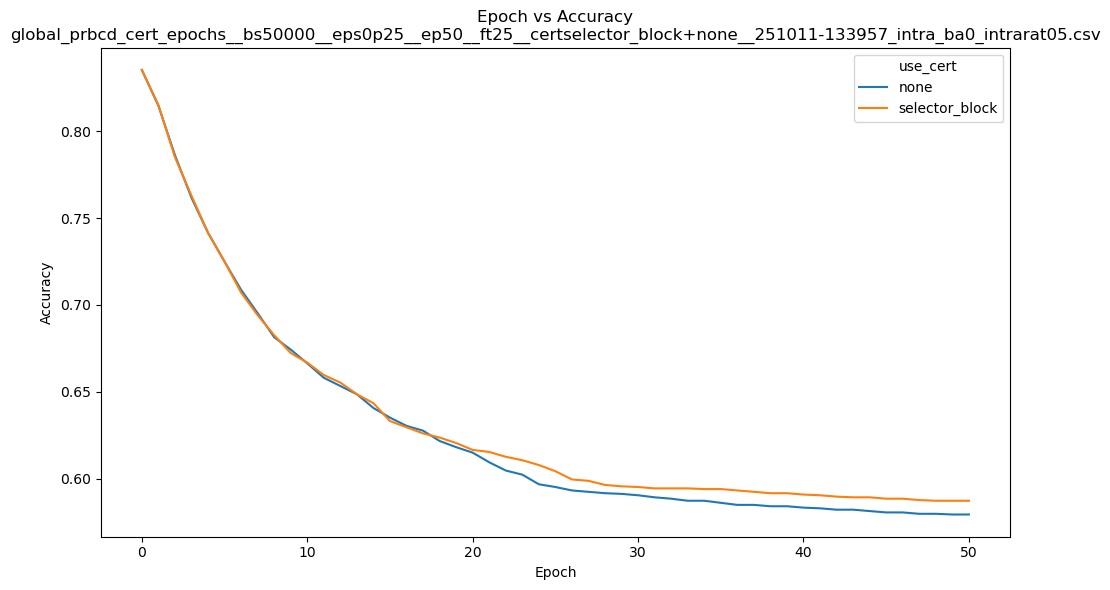

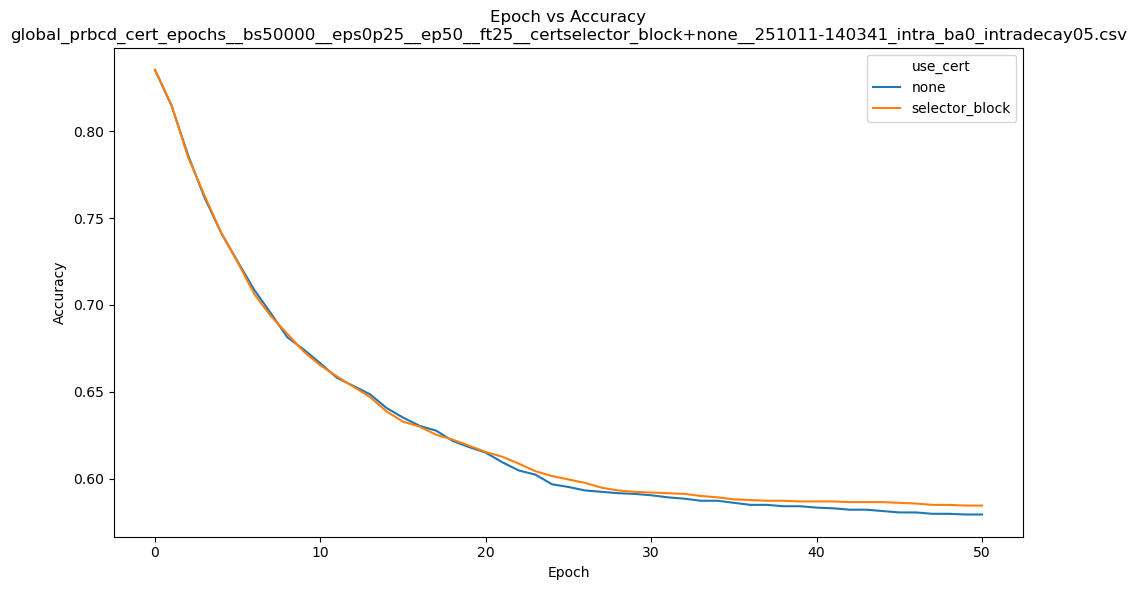

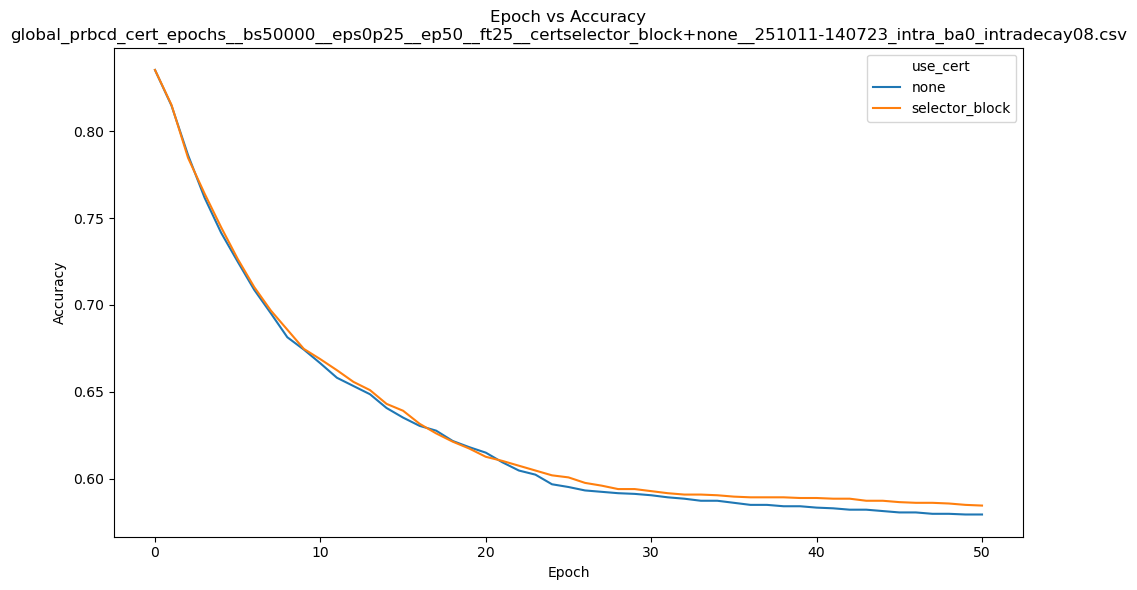

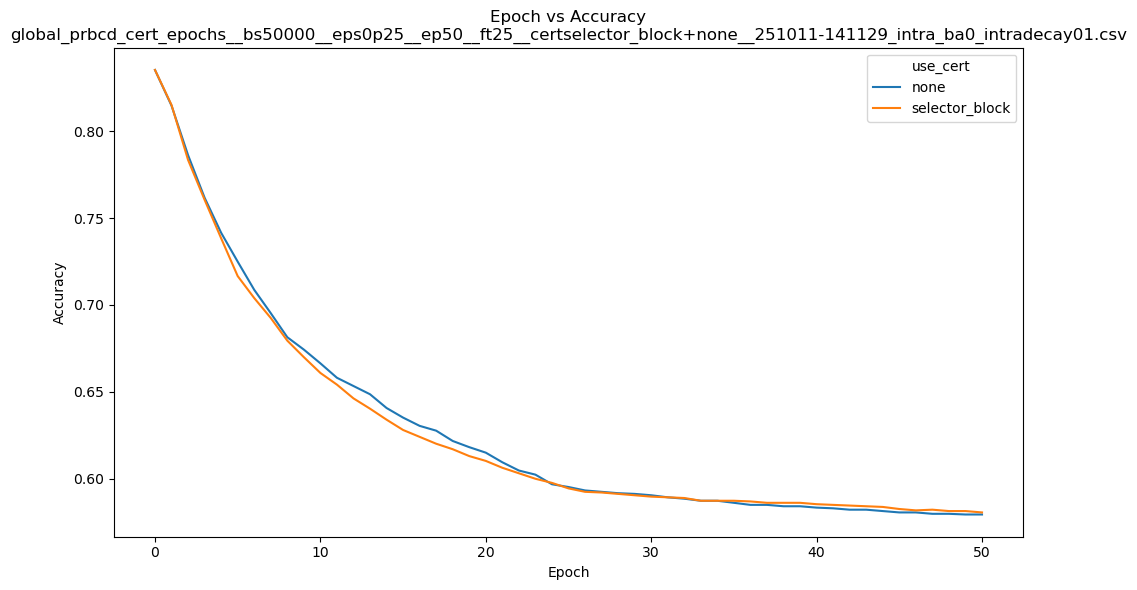

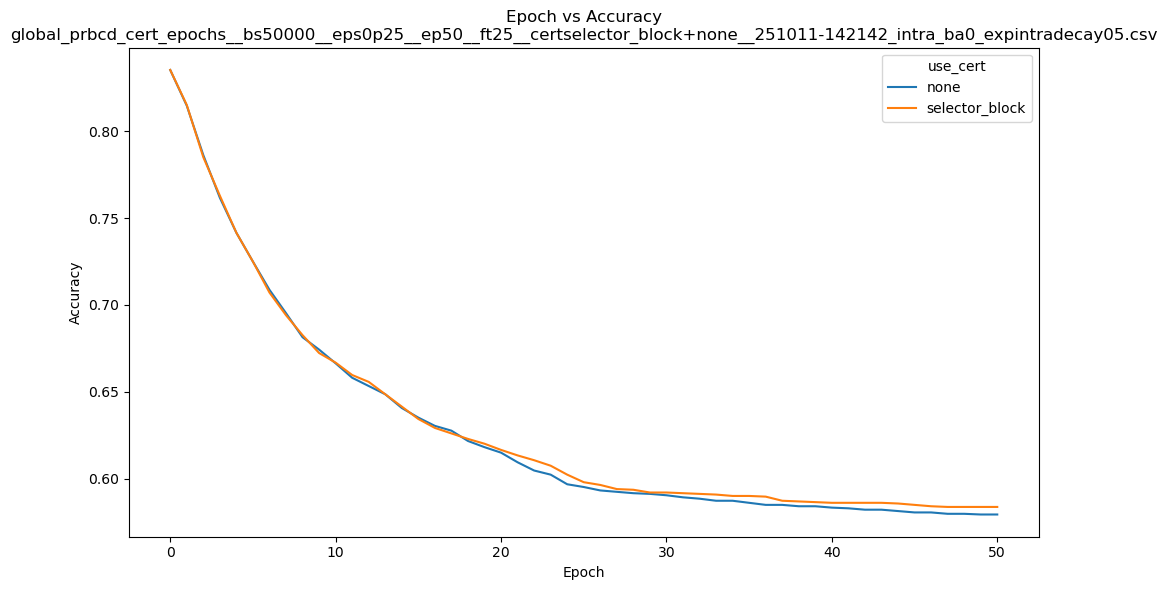

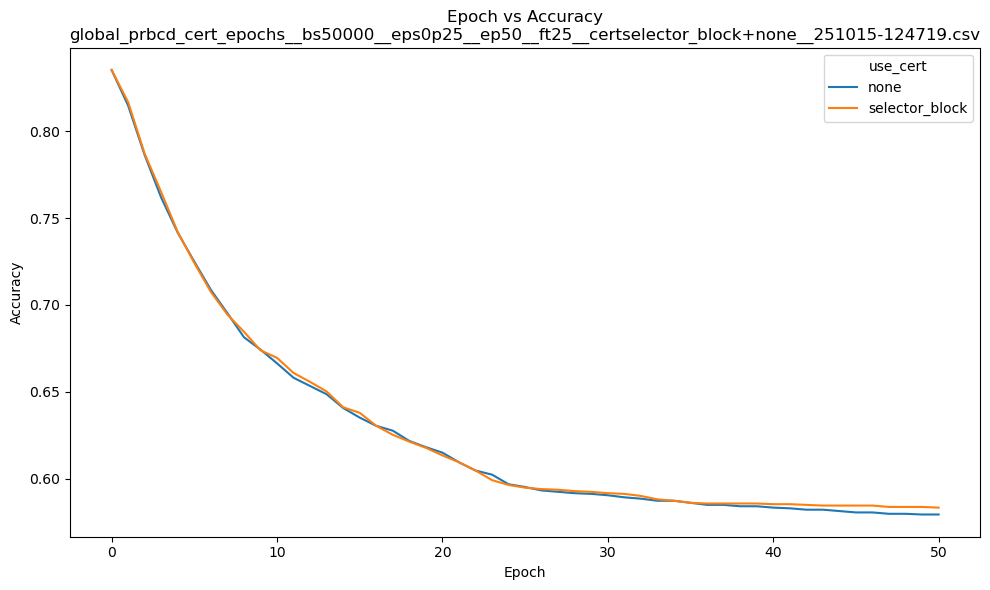

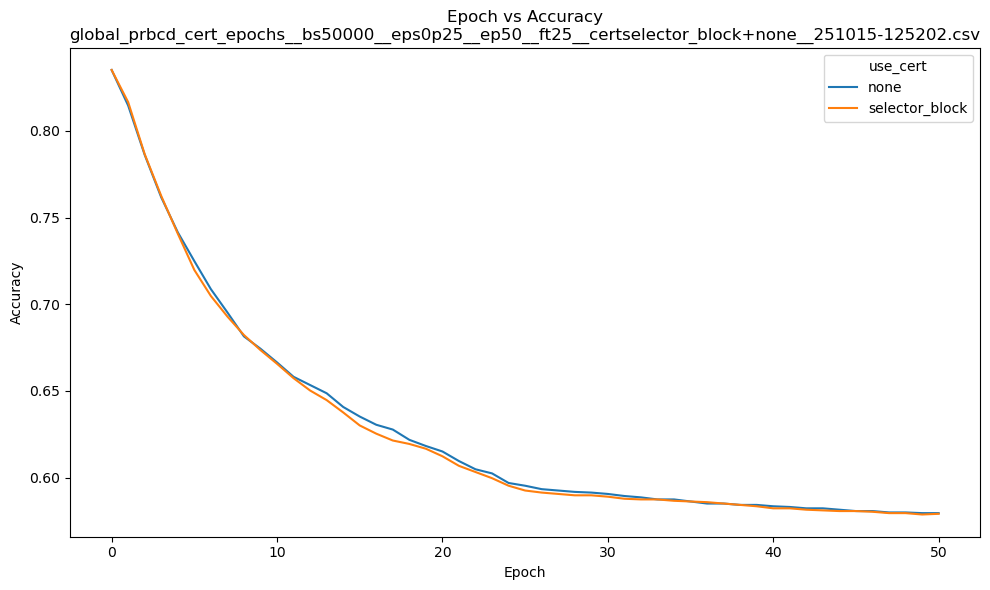

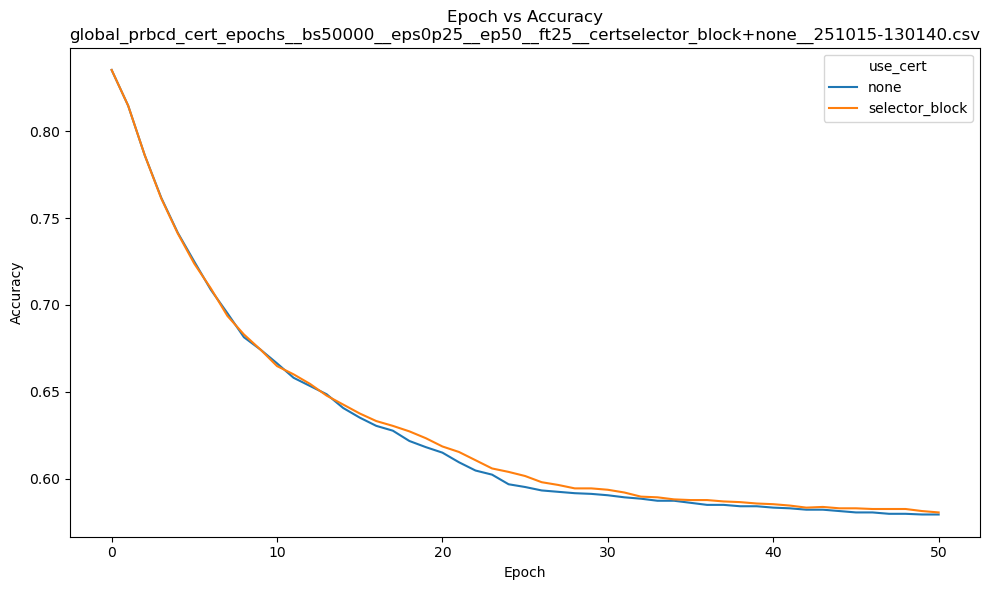

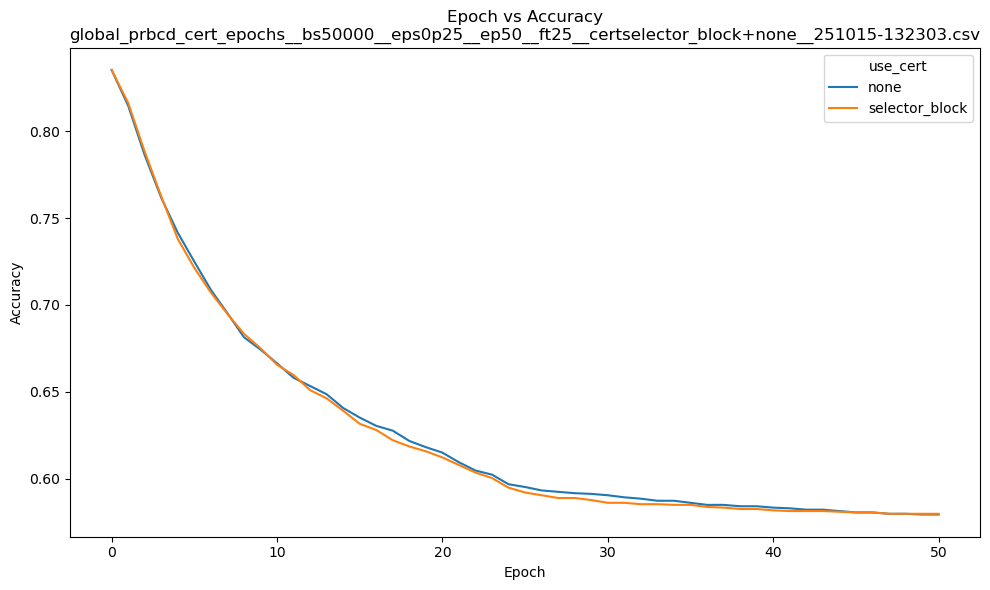

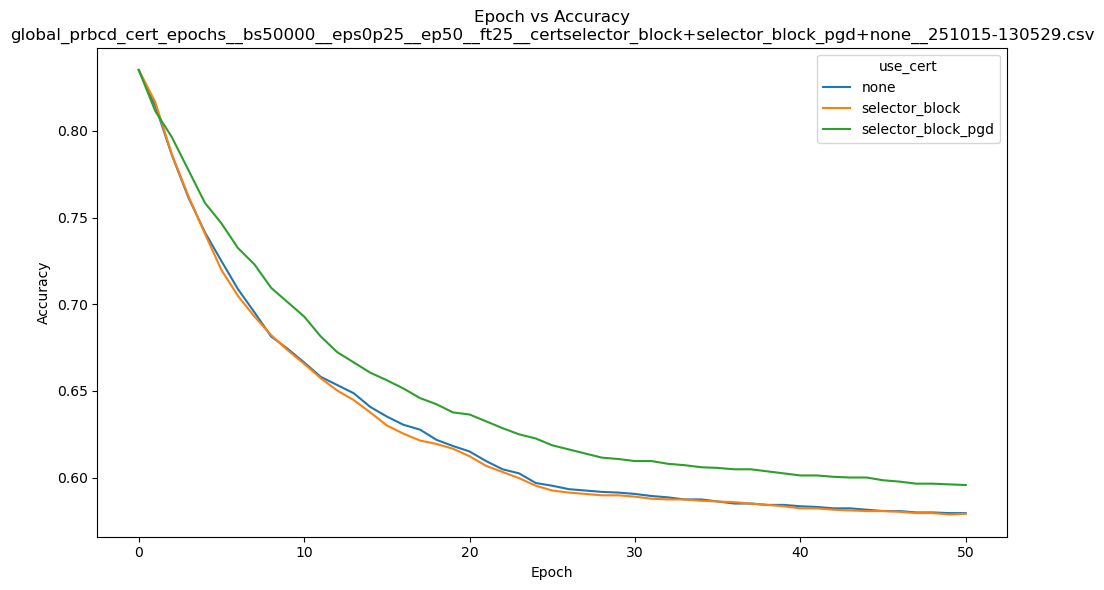

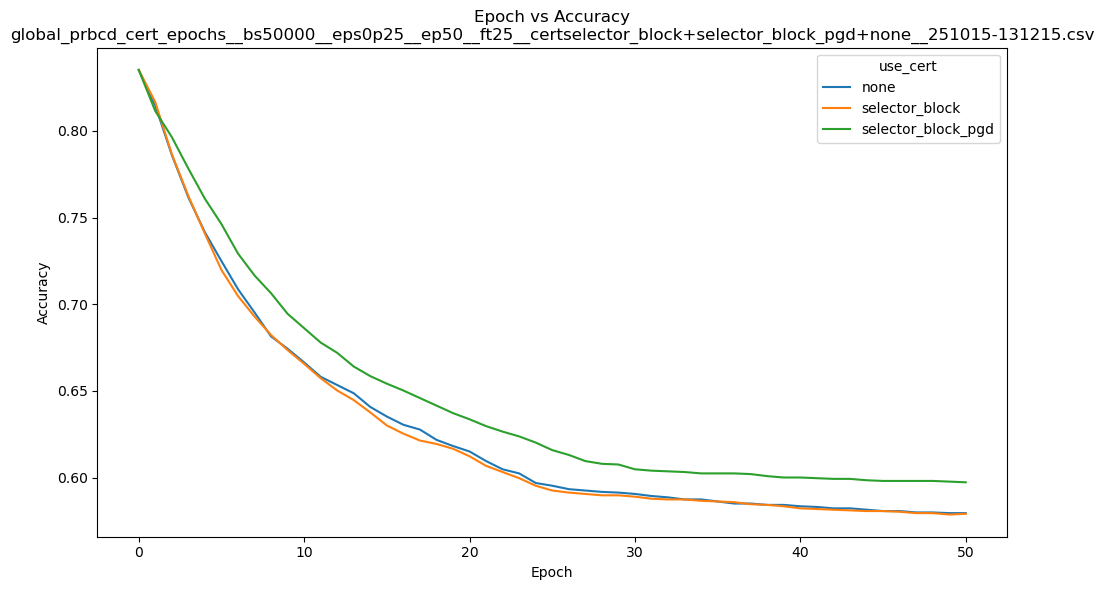

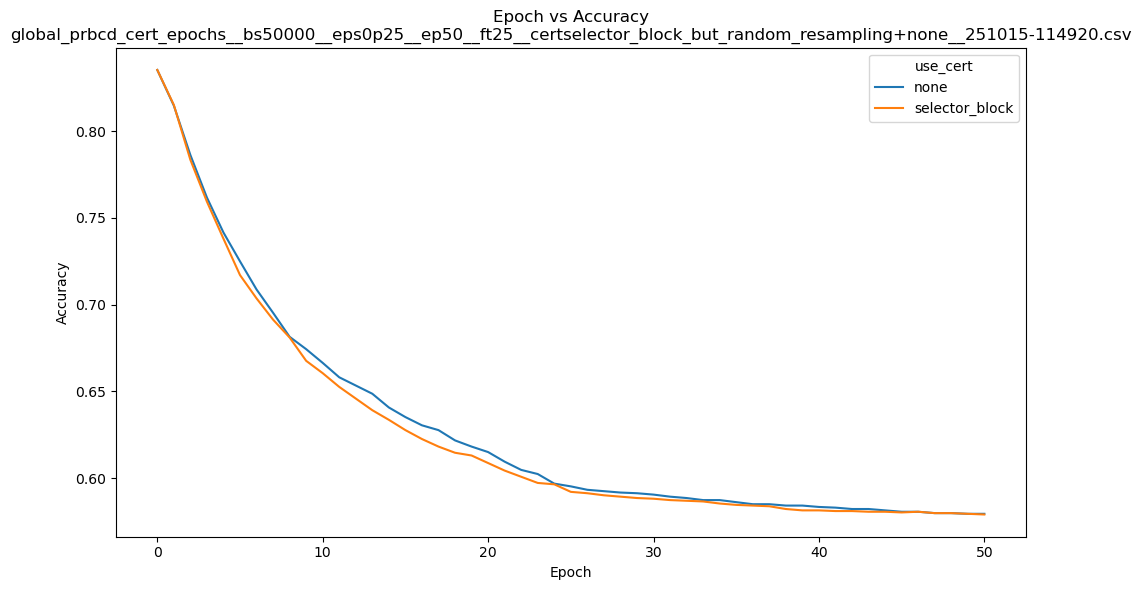

C:\Users\Schulz\AppData\Local\Temp\ipykernel_20040\1567914378.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="use_cert")


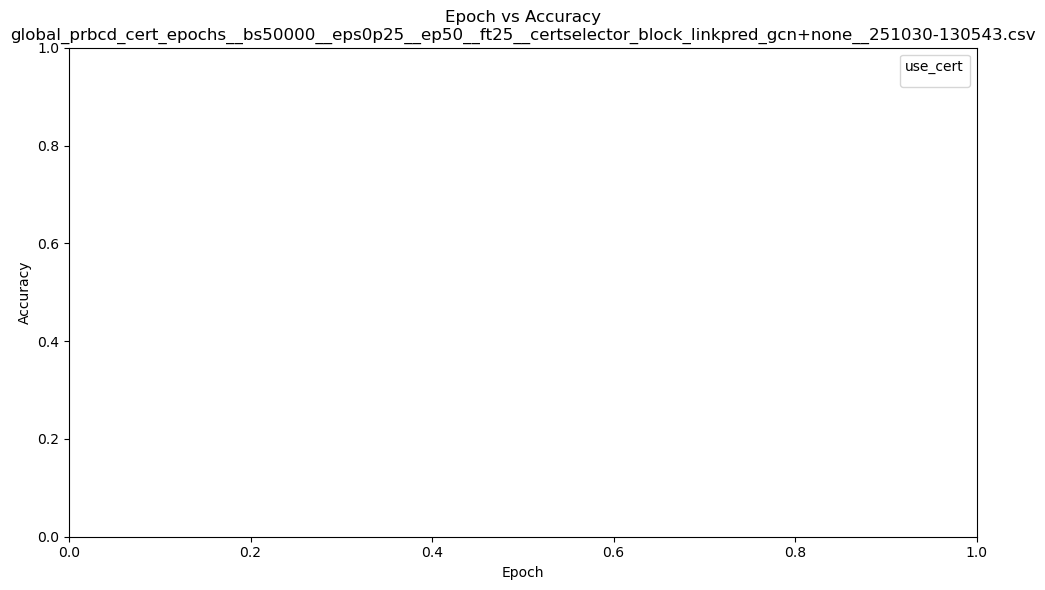

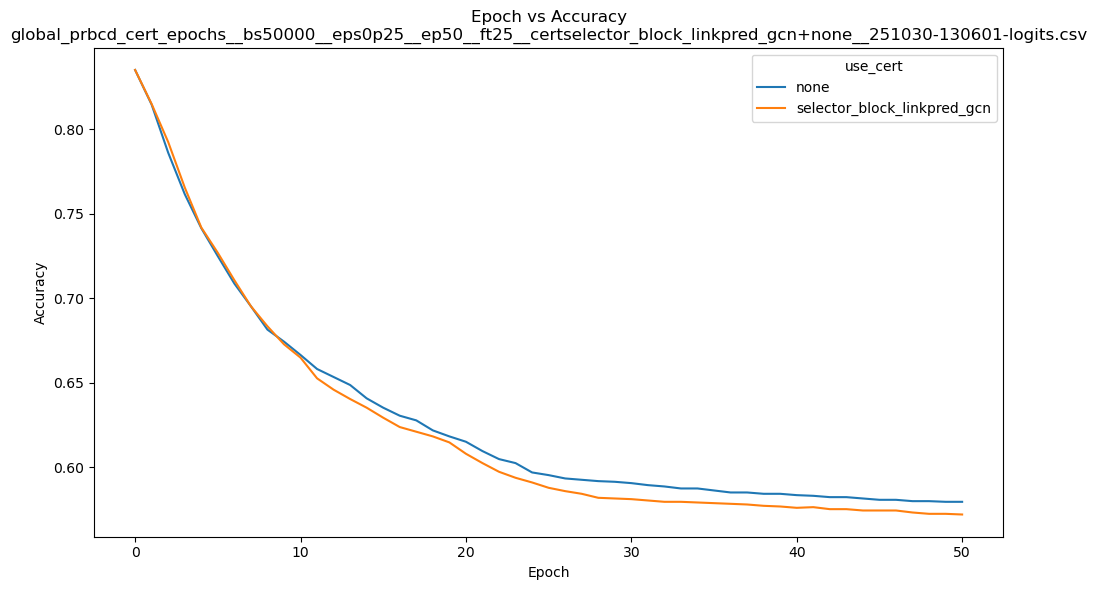

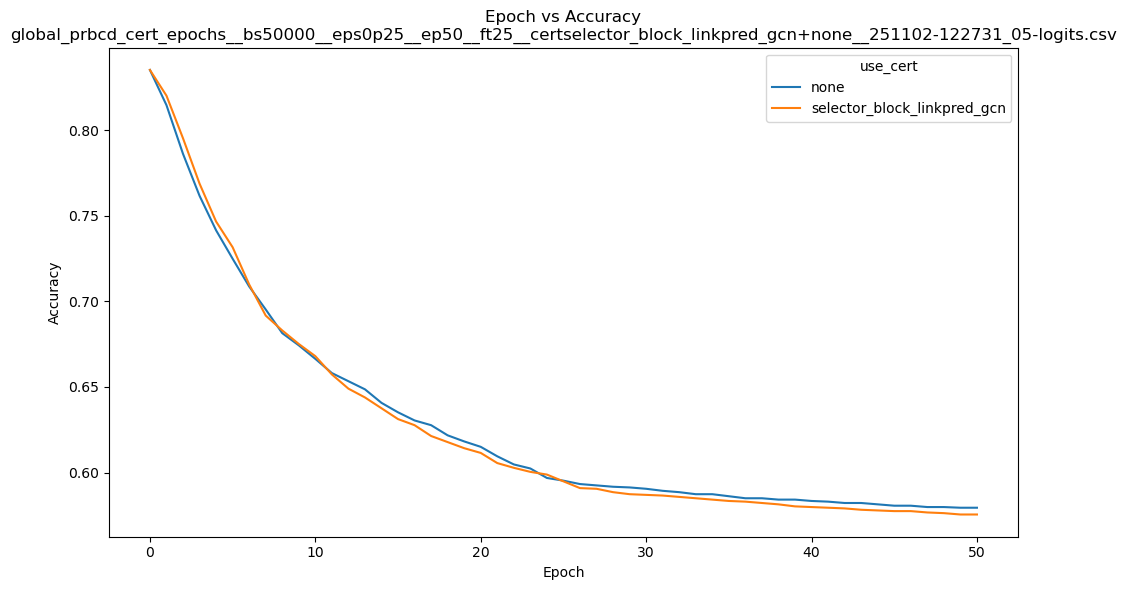

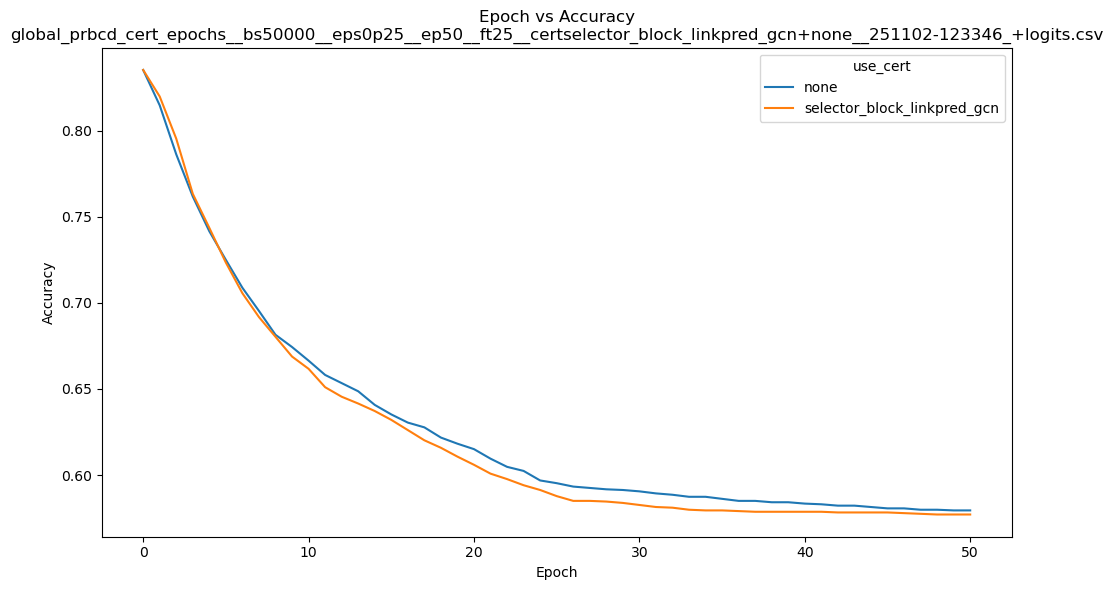

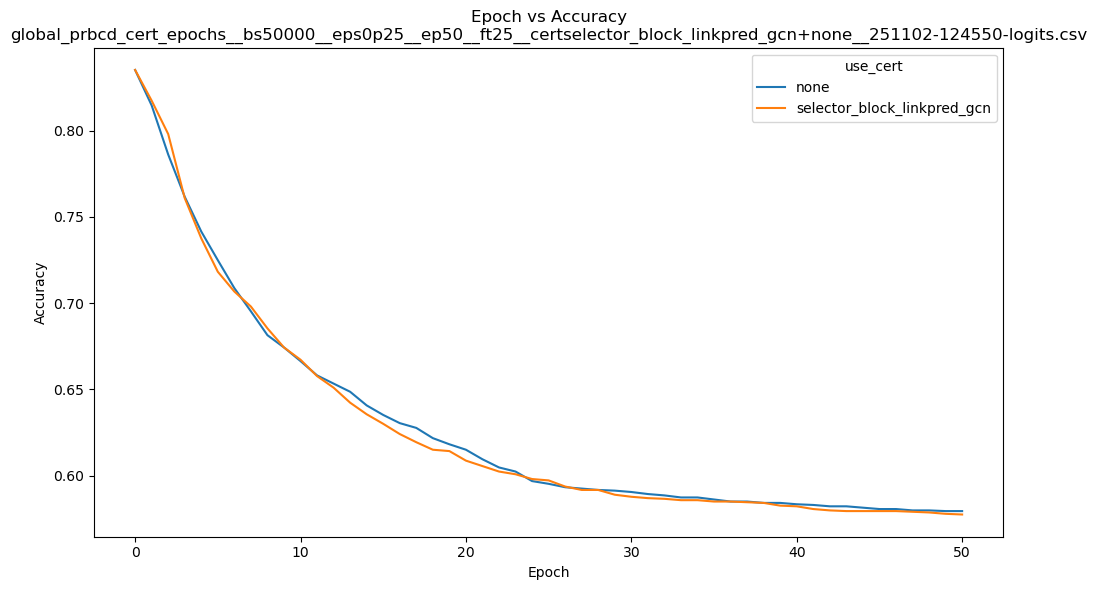

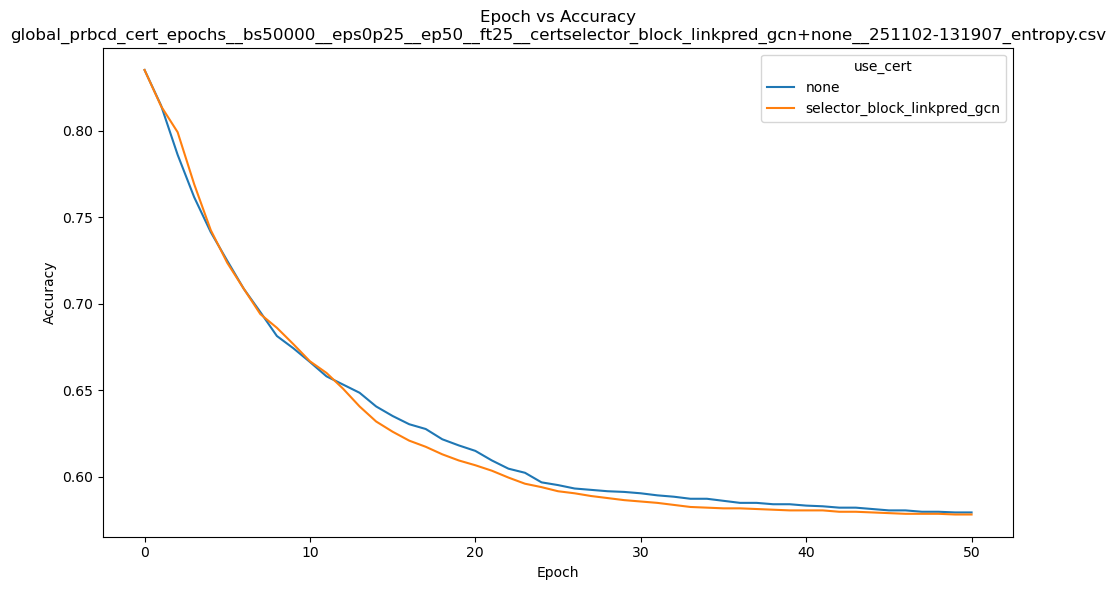

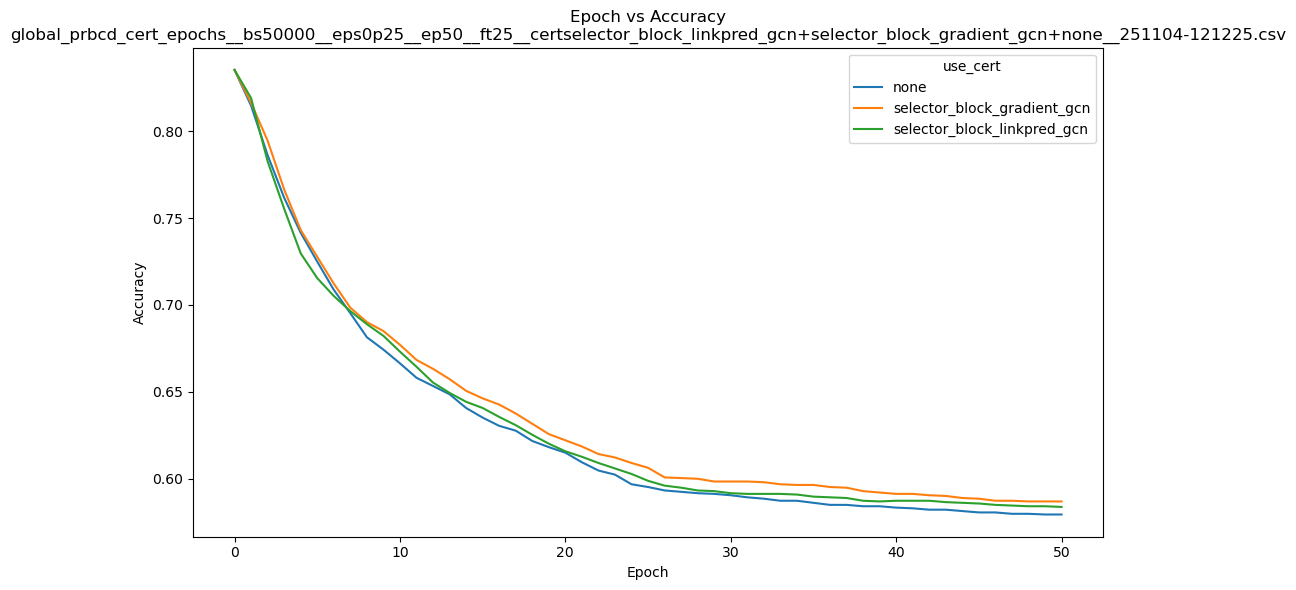

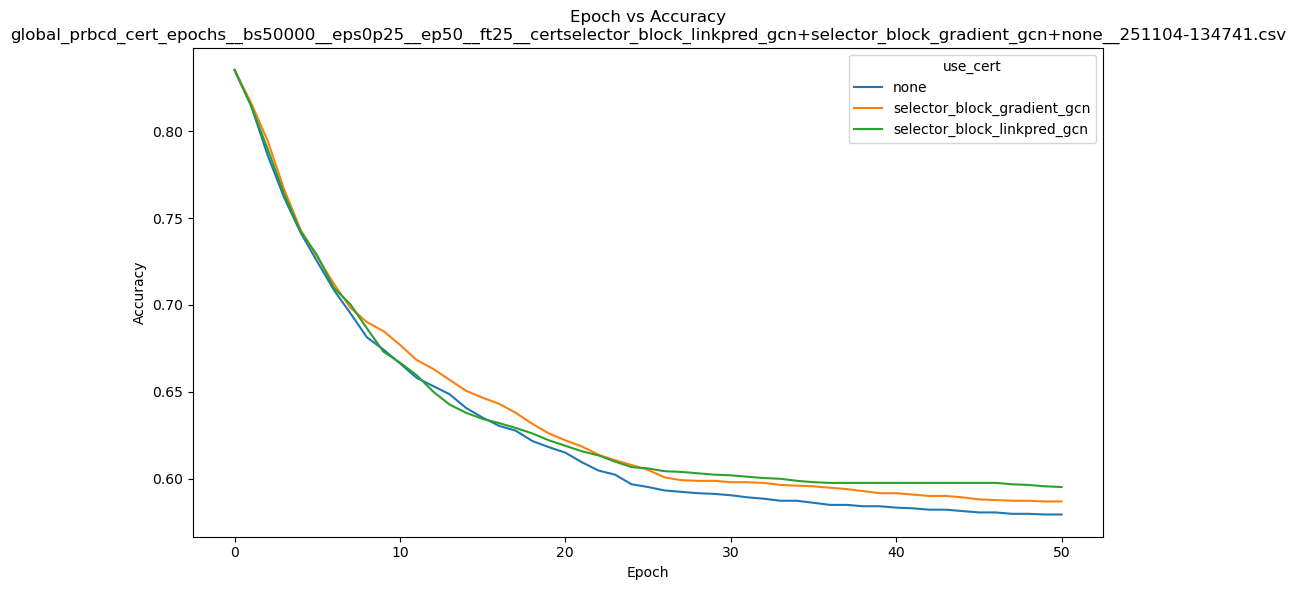

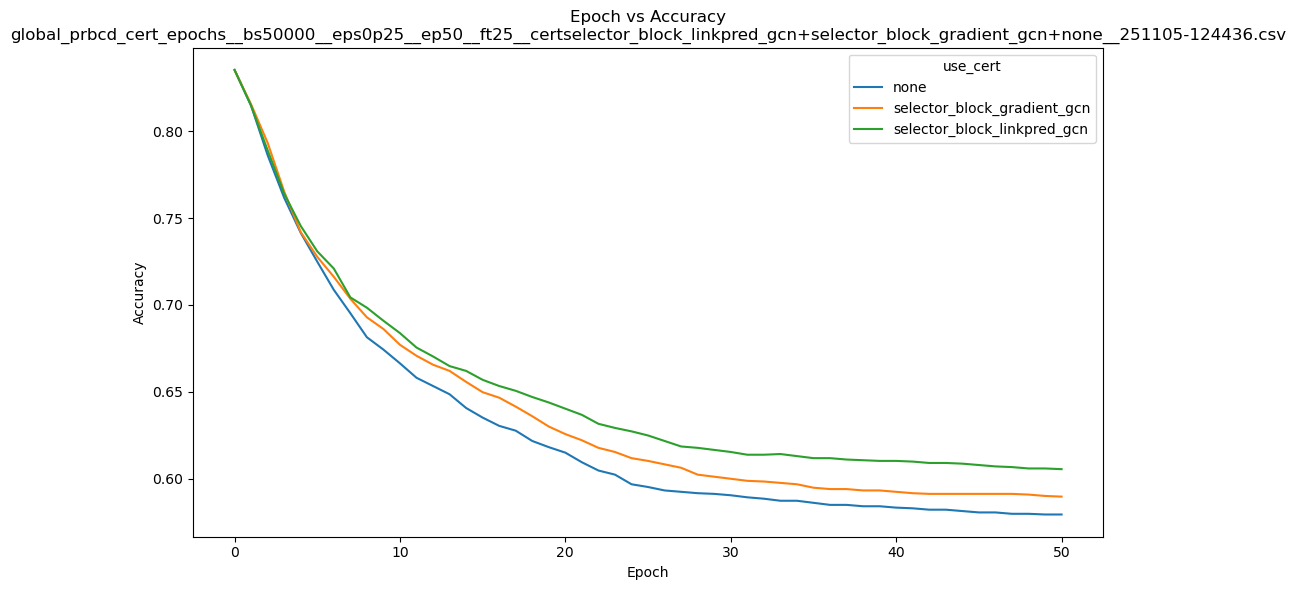

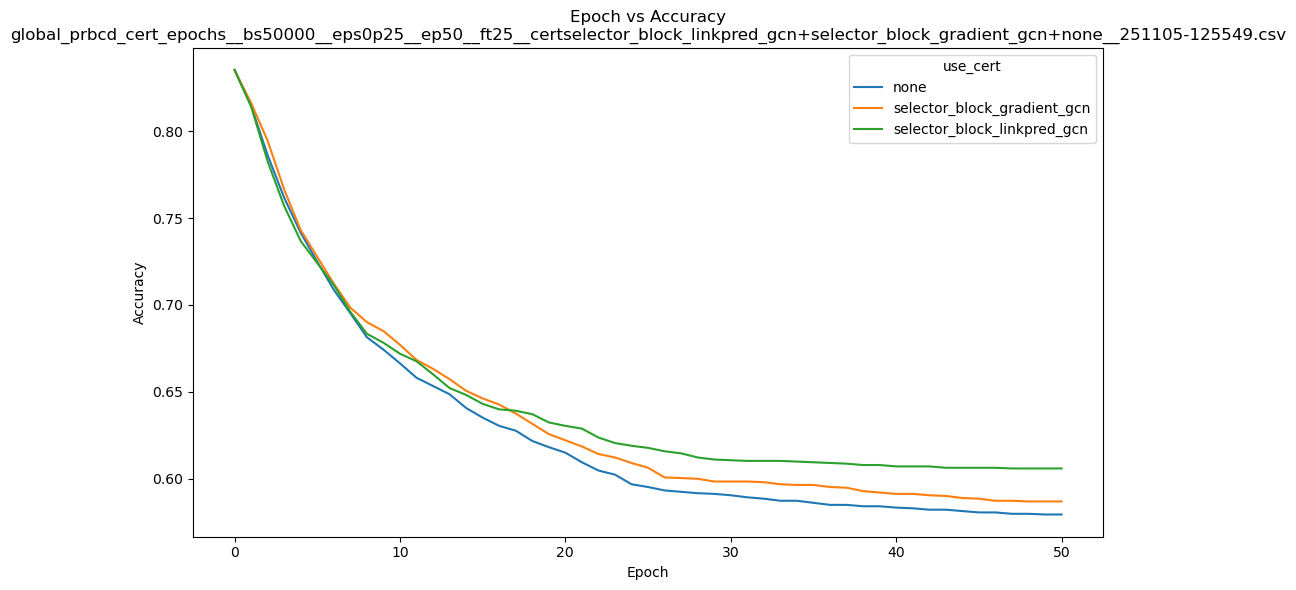

C:\Users\Schulz\AppData\Local\Temp\ipykernel_20040\1567914378.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="use_cert")


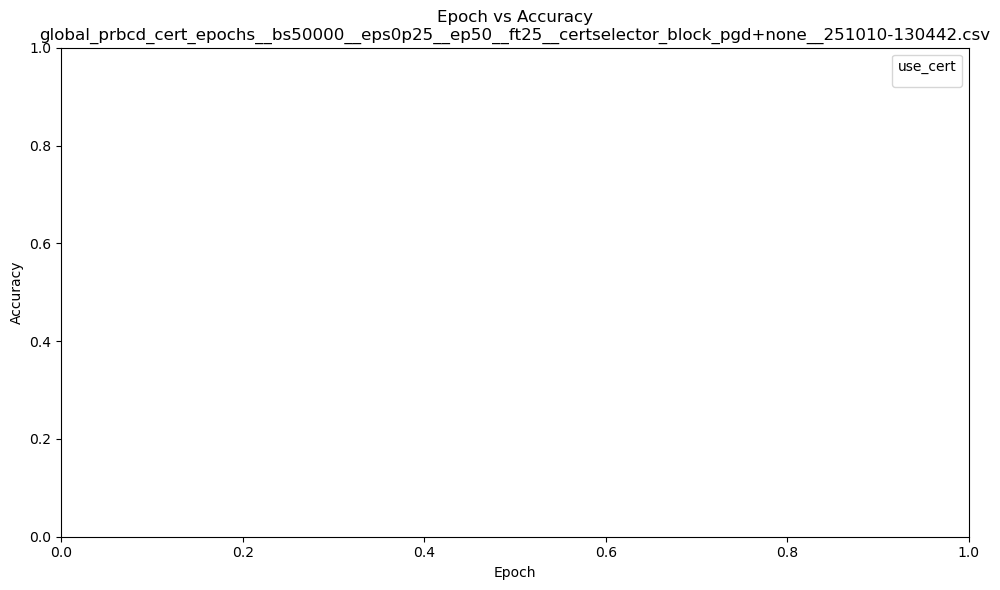

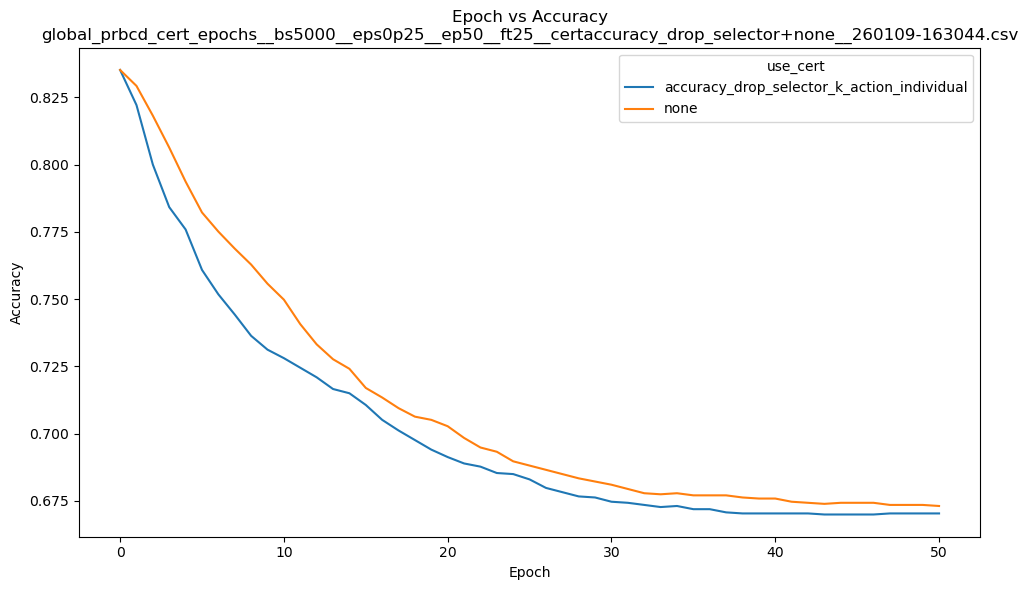

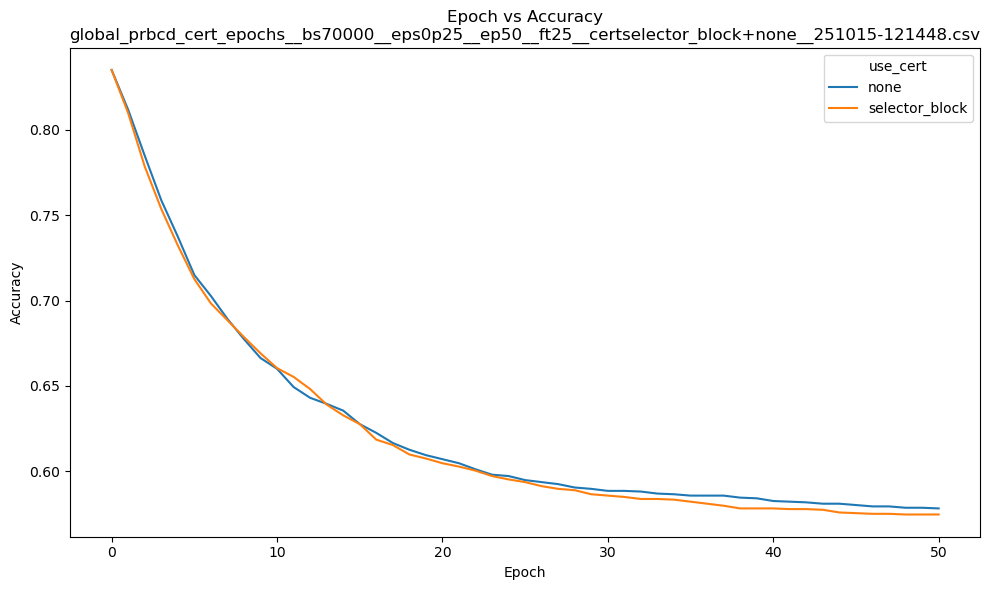

In [19]:

import os
import pandas as pd
import matplotlib.pyplot as plt

# Folder containing CSVs
csv_folder = "Plotting_Data"

# Collect relevant CSVs
csv_files = [
    os.path.join(csv_folder, f)
    for f in os.listdir(csv_folder)
    if f.endswith(".csv") and "global_prbcd_cert_epochs" in f
]

if not csv_files:
    raise FileNotFoundError("No matching CSV files found in Plotting_Data/")

# Candidates for column names
epoch_candidates = ["epoch_idx", "epoch", "Epoch", "step"]
acc_candidates   = ["accuracy", "acc", "Accuracy"]

for csv_path in csv_files:
    df = pd.read_csv(csv_path)

    # Figure out epoch and accuracy columns
    epoch_col = next((c for c in epoch_candidates if c in df.columns), None)
    acc_col   = next((c for c in acc_candidates   if c in df.columns), None)

    if epoch_col is None or acc_col is None:
        print(f" Skipping {csv_path} (no epoch/accuracy column found)")
        continue

    # Cast to numeric
    df[epoch_col] = pd.to_numeric(df[epoch_col], errors="coerce")
    df[acc_col]   = pd.to_numeric(df[acc_col], errors="coerce")
    df = df.dropna(subset=[epoch_col, acc_col])

    plt.figure(figsize=(10,6))

    '''
    if "use_cert" in df.columns:
        for method, g in df.groupby("use_cert"):
            series = g.groupby(epoch_col)[acc_col].mean().sort_index()
            plt.plot(series.index.values, series.values, label=str(method))
        plt.legend(title="use_cert")
    else:
        series = df.groupby(epoch_col)[acc_col].mean().sort_index()
        plt.plot(series.index.values, series.values)
    '''
    if "use_cert" in df.columns:
        for method, g in df.groupby("use_cert"):
            if method == "accuracy_drop_selector_k_hop":
                continue

            series = g.groupby(epoch_col)[acc_col].mean().sort_index()
            plt.plot(series.index.values, series.values, label=str(method))

        plt.legend(title="use_cert")

    else:
        series = df.groupby(epoch_col)[acc_col].mean().sort_index()
        plt.plot(series.index.values, series.values)


    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Epoch vs Accuracy\n{os.path.basename(csv_path)}")
    plt.tight_layout()
    plt.show()

### 2.2.1 Global PR-BCD Attack without Cert

Now let's do the same with a non-local `PR-BCD` attack. For this, we use [experiments/experiment_global_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_global_attack_direct.py#L63).

In [ ]:
from DeleteCache import delete_pert_files_and_folders

delete_pert_files_and_folders(
    cache_dir="cache",
    pert_adj_storage_type="evasion_global_adj",
    pert_attr_storage_type="evasion_global_attr"
)

global_prbcd_statistics = experiment_global_attack_direct.run(
    data_dir = './data',
    dataset = 'cora_ml',
    attack = 'PRBCD',
    attack_params = dict(
        epochs=50,
        fine_tune_epochs=100,
        keep_heuristic="WeightOnly",
        search_space_size=100_000,
        block_size=2000,
        do_synchronize=True,
        loss_type="tanhMargin",
    ),
    epsilons = [0.25],
    binary_attr = False,
    make_undirected = True,
    seed=0,
    artifact_dir = 'cache',
    pert_adj_storage_type = 'evasion_global_adj',
    pert_attr_storage_type = 'evasion_global_attr',
    model_label = 'Vanilla GCN',
    model_storage_type = 'demo',
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    debug_level = "info",
)

print(global_prbcd_statistics)

In [ ]:
perturbed_acc_cert = global_prbcd_statistics_cert["results"][0]['accuracy']
print(f'Clean accuracy: {100*clean_acc:.2f}%; Accuracy after global PRBCD attack with cert: {100*perturbed_acc_cert:.2f}%')

In [ ]:
perturbed_acc = global_prbcd_statistics["results"][0]['accuracy']
print(f'Clean accuracy: {100*clean_acc:.2f}%; Accuracy after global PRBCD attack: {100*perturbed_acc:.2f}%')

In [ ]:

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=df_filtered,
    x="epoch",
    y="accuracy",
    hue="use_cert",
    style="use_cert",
    markers=True,
    dashes=False,
    estimator="mean"
)
